# GO Analysis for WGCNA
## Phase 2 

Gene ontology of modules from [WGCNA](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/wgcna_p2.ipynb). Following [Gurr code](https://github.com/SamGurr/Pgenerosa_OA_TagSeq/blob/main/TagSeq/Analysis/Scripts/GO_Analysis_WGCNA_all.R)

Since we don't have log fold change (because we aren't looking at differential expression), we can only do an over-representation analysis (ORA) - provide a gene list of interest (genes in a significantly correlated module) and a universal gene list (after filtering for wgcna - so *not* all genes in the CV genome, but rather what went in as input to wgcna)

## 0. load libraries

In [2]:
library(tidyverse)
library(goseq)
library(reshape2)
library(Rmisc)
library(ggpubr)
library(gridExtra)
library(forcats)
library(zoo)
library(ComplexHeatmap)
library(GO.db)
library(GSEABase)
library(clusterProfiler)

## 1. load data
WGCNA module membership, module colors, and goslim_generic.obo

#### A. gene annotation to GO.term - long format
matches GO terms to *C. virginica* genes - one GO term per row (so genes are duplicated among rows)

In [28]:
annot <- read.csv('/work/pi_sarah_gignouxwolfsohn_uml_edu/julia_mcdonough_student_uml_edu/ref_files/annotations/newRef_geneGO.csv')
colnames(annot)[1] <- 'Gene'
colnames(annot)[2] <- 'GO.terms'

# One row for each gene and GO.term
term2gene <- annot %>%
  separate_rows(GO.terms, sep = ";") %>% # one row for each GO.term
  filter(!is.na(GO.terms) & GO.terms != "") %>% # remove genes without GO terms
  dplyr::select(term = GO.terms, gene = Gene) # rename columns for GO 

# 

head(term2gene)

term,gene
<chr>,<chr>
GO:0005261,LOC111099029
GO:0005886,LOC111099029
GO:0030001,LOC111099029
GO:0098655,LOC111099029
GO:0004930,LOC111099032
GO:0005886,LOC111099032


this becomes input for `enricher` down below

get term names for GO IDs

In [41]:
# Extract GO term descriptions
go_terms <- unique(term2gene$term)

# Get descriptions from GO.db
term2name <- data.frame(
  term = go_terms,
  name = sapply(go_terms, function(x) {
    tryCatch({
      Term(GOTERM[[x]])
    }, error = function(e) {
      NA_character_
    })
  })
)

# Remove NAs
term2name <- term2name[!is.na(term2name$name), ]

# View
head(term2name)    

,term,name
,<chr>,<chr>
GO:0005261,GO:0005261,monoatomic cation channel activity
GO:0005886,GO:0005886,plasma membrane
GO:0030001,GO:0030001,metal ion transport
GO:0098655,GO:0098655,monoatomic cation transmembrane transport
GO:0004930,GO:0004930,G protein-coupled receptor activity
GO:0007186,GO:0007186,G protein-coupled receptor signaling pathway


#### B. GOslim data

GO Slim - higher level of GO used to summarize GO results into broader categories (the parent terms)

In [5]:
slim <- getOBOCollection("http://current.geneontology.org/ontology/subsets/goslim_generic.obo")
class(slim)

[1] "OBOCollection"
attr(,"package")
[1] "GSEABase"

In [6]:
# 1. Get the GO IDs
slim_ids <- ids(slim)

# 2. Get the IDs that belong to the generic subset
slim_ids <- ids(slim["goslim_generic" ])

# 3. Get the terms for those specific IDs
# use the GO.db package because it's much faster and more reliable for names
slim_terms <- Term(slim_ids)

# 4. Create lookup table 
slim_lookup <- data.frame(
  SlimID = names(slim_terms), # parent ID
  GOSlim_Bin = as.character(slim_terms), # biological term
  stringsAsFactors = FALSE
)

head(slim_lookup)

,SlimID,GOSlim_Bin
,<chr>,<chr>
1,GO:0000228,nuclear chromosome
2,GO:0000278,mitotic cell cycle
3,GO:0000910,cytokinesis
4,GO:0001618,virus receptor activity
5,GO:0002181,cytoplasmic translation
6,GO:0002376,immune system process


this table can be used to assign GO terms to broader categories - however, this table only contains parent terms (SlimID), so cannot directly be merged with GO results - need to match the parent terms to the GO IDs

In [7]:
# 1. Get a list of all ancestors for every GO term in WGCNA results
# This creates a mapping of Specific_ID -> All_Ancestors
all_ancestors <- as.list(GOBPANCESTOR)

# lookup vector - parent GO terms
target_slim_ids <- unique(slim_lookup$SlimID)

# 2. make lookup function
find_slim_parent <- function(specific_id, slim_ids) {
  if (is.na(specific_id)) return(NA_character_) # if GO term isn't in ancestor lookup
  if (specific_id %in% slim_ids) return(specific_id) # if GO term is the parent term
  
  # Get ancestors from the GO.db object
  ancestors <- all_ancestors[[specific_id]]
  
  if (is.null(ancestors)) return(NA_character_) # if no ancestor term
  
  # Find which ancestors are in your Slim list
  match <- intersect(ancestors, slim_ids)
  
  if (length(match) == 0) return(NA_character_)
  return(as.character(match[1])) 
}


#### C. Gene info
read in gene info from [wgcna_p2.ipynb](https://github.com/jgmcdonough/CE24_RNA-seq/blob/main/analysis/diff_expression/phase2_v_phase2/wgcna/wgcna_p2.ipynb)

contains the gene name, matching GO terms, module color, gene significance (GS) for every treatment, and module membership (MM) for each module

In [9]:
geneInfo <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/p2.wgcna_GeneInfo.csv') 
head(geneInfo) 

,Gene,GO.terms,ModuleColor,Combo_treatments.GS.both_both,Combo_treatments.GS.both_warm,Combo_treatments.GS.both_control,Combo_treatments.GS.both_hypoxic,Combo_treatments.GS.control_hypoxic,Combo_treatments.GS.control_both,Combo_treatments.GS.control_control,⋯,MMmidnightblue,MMblack,MMyellow,MMcyan,MMturquoise,MMsalmon,MMtan,MMgreenyellow,MMgreen,MMred
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,yellow,-0.01495044,0.009030399,-0.04316368,-0.085413908,-0.04374884,-0.0729733470,-0.00471465,⋯,0.065460089,-0.018296558,0.06646763,-0.13317516,-0.031858336,-0.01124888,0.02333575,0.06322218,0.2211404,0.12461204
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,midnightblue,0.14459247,-0.064829675,-0.06181353,-0.061718773,0.15599740,0.1040893959,-0.06447848,⋯,0.748900339,0.327570333,0.39804191,-0.04937016,-0.078146300,-0.10142873,-0.01492029,-0.24537144,-0.1083778,-0.21658264
3,LOC111099040,GO:0005515;GO:0007169;GO:0035556,greenyellow,0.11681949,0.006899984,0.18134237,0.313437234,0.20532184,0.0718962563,-0.11146323,⋯,-0.115310362,-0.117876698,0.05946136,-0.13105088,-0.064554246,0.04518120,0.09161650,0.35226238,0.2200053,-0.04466655
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,green,0.14136041,0.065349310,-0.10640160,0.128461971,-0.07462762,-0.0004772388,-0.15790529,⋯,0.006388863,0.229504381,0.02044144,0.13357465,-0.005118615,0.33307009,0.24671309,0.21709977,0.4433002,0.15647982
5,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,green,0.04364955,0.145555981,-0.08304872,0.155151519,0.03698424,0.2778968873,-0.21252303,⋯,-0.112655485,-0.008789098,-0.01210893,0.01072442,0.152950645,0.05420974,0.28229826,0.14856114,0.3971374,0.14279690
6,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,red,-0.04705534,-0.010491654,-0.08949085,0.002778676,0.09915982,-0.0823056472,0.05071313,⋯,-0.098692689,0.158466514,0.09721454,0.19773948,0.192763544,0.29045733,0.40240572,0.22677789,0.3603098,0.55047256


categorize gene info columns

In [10]:
# Get all column names once
all_cols <- names(geneInfo)

# 1. The 16 'Combo_treatments.GS' columns
combo_cols <- grep("^Combo_treatments\\.GS\\.", all_cols, value = TRUE)

# 2. Phase 1 & 2 Driver columns (Temp and DO)
p1_driver_cols <- grep("^phase1_(temp|DO)\\.GS\\.", all_cols, value = TRUE)
p2_driver_cols <- grep("^phase2_(temp|DO)\\.GS\\.", all_cols, value = TRUE)

# 3. Overall Phase Treatment columns
p1_overall_cols <- grep("^phase1_treatment\\.GS\\.", all_cols, value = TRUE)
p2_overall_cols <- grep("^phase2_treatment\\.GS\\.", all_cols, value = TRUE)

# 4. Module Membership (MM) colors
mm_cols <- grep("^MM", all_cols, value = TRUE)

#### Module membership
pull out just the genes, associated GO terms, and which module they're been assigned to

In [11]:
moduleMembership <-  geneInfo %>% dplyr::select(Gene, GO.terms, ModuleColor) # select for genes, GO.ids, modules
head(moduleMembership)

,Gene,GO.terms,ModuleColor
,<chr>,<chr>,<chr>
1,LOC111099029,GO:0005261;GO:0005886;GO:0030001;GO:0098655,yellow
2,LOC111099037,GO:0000978;GO:0000981;GO:0006355,midnightblue
3,LOC111099040,GO:0005515;GO:0007169;GO:0035556,greenyellow
4,LOC111099041,GO:0016020;GO:0022857;GO:0055085,green
5,LOC111099043,GO:0005222;GO:0005223;GO:0005886;GO:0017071;GO:0030553;GO:0044877;GO:0098655,green
6,LOC111099050,GO:0005515;GO:0006886;GO:0031462;GO:0043161;GO:1990756,red


#### D. universal list
this is the input gene list for wgcna before module assignment, but after gene filtering

In [24]:
universal_genes <- read.csv('/project/pi_sarah_gignouxwolfsohn_uml_edu/julia/CE_2024/CE24_RNA-seq/analysis/diff_expression/phase2_v_phase2/new_refGenome/wgcna/p2.wgcna_UniversalGeneList.csv')
head(universal_genes)

,gene
,<chr>
1,LOC144621260
2,LOC144621269
3,LOC111120925
4,LOC144621283
5,LOC144621276
6,LOC111115920


## 2. run GO enrichment
over-representation analysis

#### input data:
- universal_genes
- term2gene (matches gene LOC to GO term)
- term2name (matches GO term to GO description)
- geneInfo (output from WGCNA)

slim_lookup for matching parent GO terms to GO results

### brown module

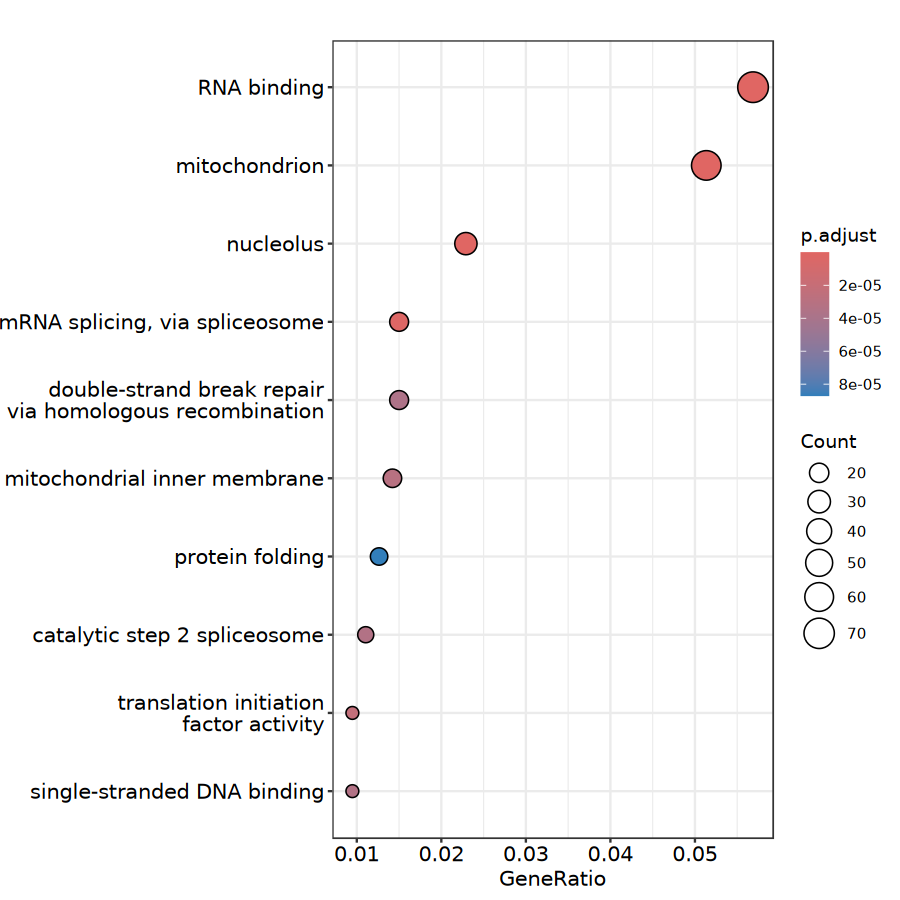

In [52]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

# brown 
target_genes <- geneInfo %>%
  filter(ModuleColor == "brown") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
brown_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

In [53]:
brown_mapped <- brown_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
brown_final <- brown_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'brown'")

head(brown_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0003723,RNA binding,72/1266,223/9340,2.798794e-13,1.038352e-10,8.632069e-11,LOC111099922/LOC111103914/LOC111104149/LOC111105897/LOC111107584/LOC111111061/LOC111111718/LOC111112016/LOC111112550/LOC111112585/LOC111112733/LOC111113059/LOC111113115/LOC111116966/LOC111117964/LOC111118049/LOC111118069/LOC111118140/LOC111118362/LOC111118539/LOC111118739/LOC111118852/LOC111119023/LOC111119055/LOC111120664/LOC111120828/LOC111120891/LOC111120897/LOC111120899/LOC111121238/LOC111123381/LOC111125369/LOC111126802/LOC111127420/LOC111128022/LOC111128711/LOC111128922/LOC111129406/LOC111129496/LOC111129712/LOC111129853/LOC111130348/LOC111130461/LOC111130503/LOC111130565/LOC111130828/LOC111132975/LOC111133148/LOC111133159/LOC111133382/LOC111133458/LOC111133504/LOC111134482/LOC111134501/LOC111134942/LOC111135336/LOC111135391/LOC111135640/LOC111136320/LOC111136413/LOC111138305/LOC111138309/LOC111138363/LOC144618177/LOC144619028/LOC144622099/LOC144622109/LOC144622290/LOC144623848/LOC144625443/LOC144625869/LOC144626230,72,GO:0003723,RNA binding,'brown'
GO:0005730,nucleolus,29/1266,61/9340,1.380650e-10,2.561105e-08,2.129107e-08,LOC111103620/LOC111110332/LOC111118069/LOC111118739/LOC111118852/LOC111120892/LOC111120897/LOC111121751/LOC111123381/LOC111125438/LOC111127822/LOC111128527/LOC111129839/LOC111129891/LOC111130371/LOC111130503/LOC111132132/LOC111133059/LOC111133335/LOC111133926/LOC111134594/LOC111134754/LOC111135336/LOC111135538/LOC111135565/LOC111135974/LOC111136220/LOC144620872/LOC144626880,29,GO:0005730,nucleolus,'brown'
GO:0005739,mitochondrion,65/1266,230/9340,2.328753e-09,2.879891e-07,2.394122e-07,LOC111099882/LOC111100042/LOC111100768/LOC111103557/LOC111103813/LOC111104191/LOC111104314/LOC111104353/LOC111104483/LOC111105388/LOC111105692/LOC111105866/LOC111105912/LOC111107126/LOC111114229/LOC111115725/LOC111117758/LOC111118028/LOC111118056/LOC111118131/LOC111118249/LOC111120704/LOC111120825/LOC111120828/LOC111120899/LOC111121154/LOC111121171/LOC111121268/LOC111121506/LOC111125126/LOC111127195/LOC111127785/LOC111127815/LOC111127891/LOC111127947/LOC111127953/LOC111128143/LOC111128270/LOC111128646/LOC111129097/LOC111129316/LOC111129959/LOC111130025/LOC111130538/LOC111130742/LOC111132130/LOC111132779/LOC111133477/LOC111133661/LOC111133858/LOC111134378/LOC111134424/LOC111134852/LOC111135360/LOC111135445/LOC111136048/LOC111136154/LOC111136221/LOC111136260/LOC111138406/LOC144619508/LOC144622705/LOC144622927/LOC144626864/LOC144627595,65,GO:0005739,mitochondrion,'brown'
GO:0000398,"mRNA splicing, via spliceosome",19/1266,36/9340,2.465774e-08,2.287005e-06,1.901242e-06,LOC111099922/LOC111103914/LOC111104149/LOC111106006/LOC111106208/LOC111107428/LOC111111061/LOC111118194/LOC111118582/LOC111119018/LOC111119055/LOC111121238/LOC111134756/LOC111135499/LOC111136320/LOC111138363/LOC111138391/LOC144619426/LOC144622290,19,GO:0016071,mRNA metabolic process,'brown'
GO:0000724,double-strand break repair via homologous recombination,19/1266,43/9340,8.922336e-07,3.677985e-05,3.057596e-05,LOC111100611/LOC111103091/LOC111103948/LOC111110332/LOC111116012/LOC111120888/LOC111121716/LOC111128268/LOC111130258/LOC111130364/LOC111130622/LOC111130645/LOC111135650/LOC111136054/LOC144623221/LOC144623312/LOC144625441/LOC144625895/LOC144627387,19,GO:0006281,DNA repair,'brown'
GO:0006457,protein folding,16/1266,34/9340,2.348111e-06,8.711492e-05,7.242069e-05,LOC111100668/LOC111104099/LOC111106300/LOC111107136/LOC111113446/LOC111120649/LOC111120828/LOC111121532/LOC111121539/LOC111125459/LOC111128545/LOC111128611/LOC111128632/LOC111128939/LOC111130072/LOC111134667,16,GO:0006457,protein folding,'brown'


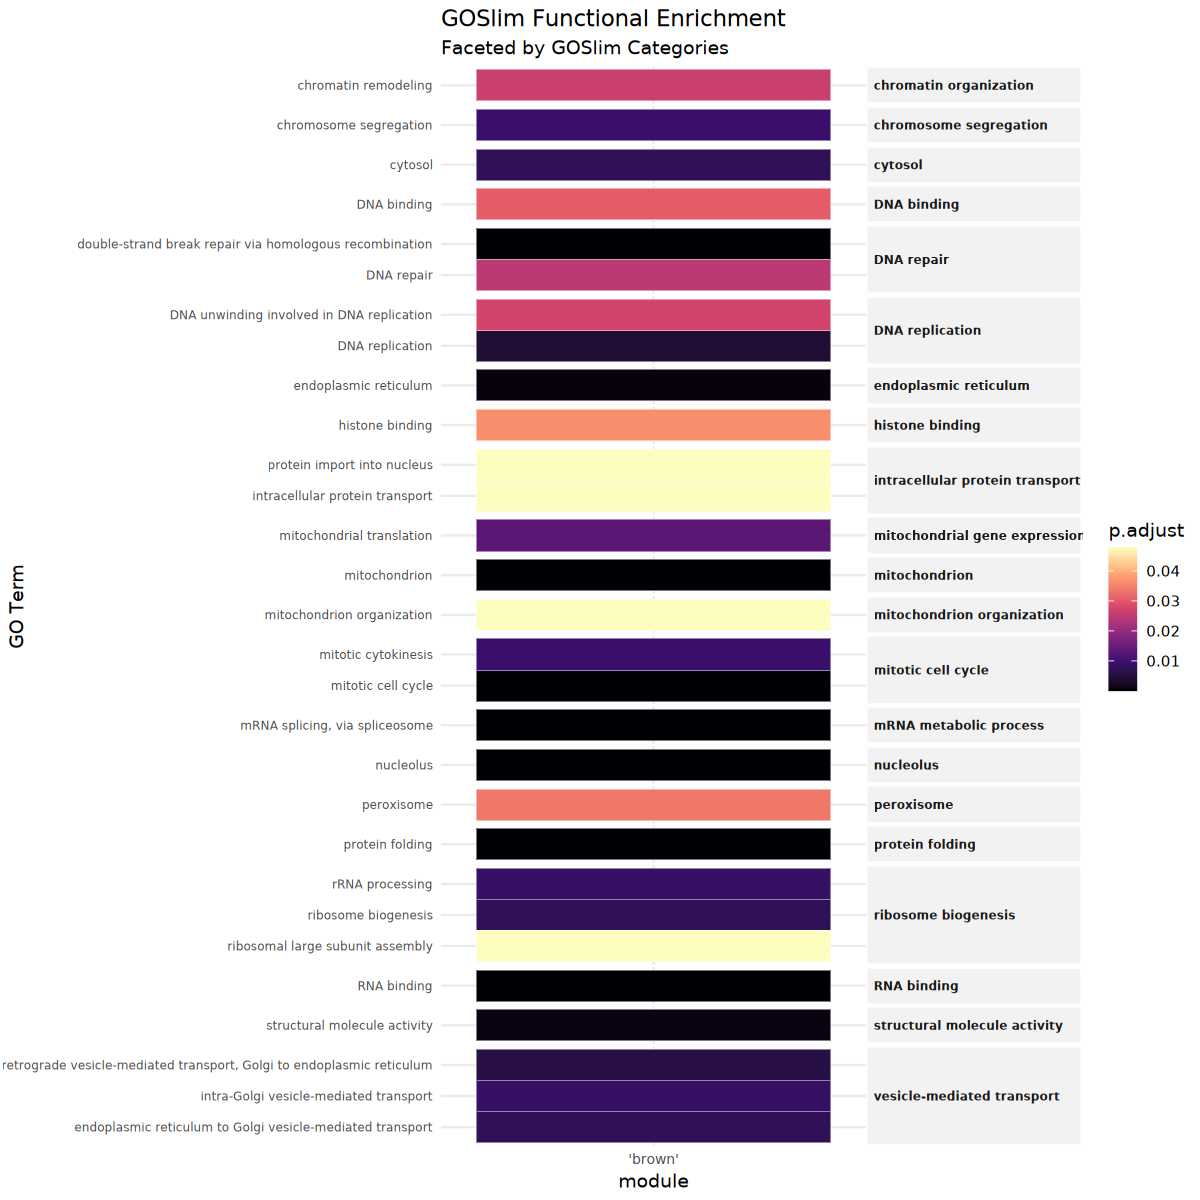

In [54]:
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(brown_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

### green module
significantly correlated with downreg in P2 control, pos reg in P2 warm (so P2 treatment and not temp)

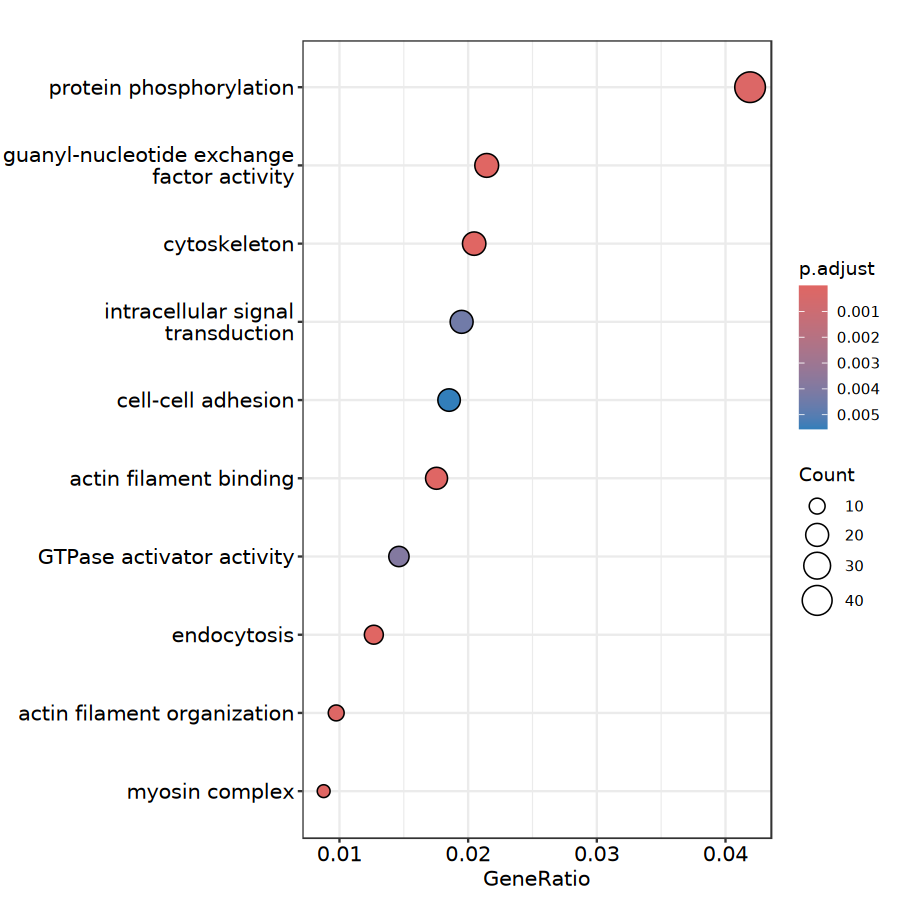

In [46]:
# green blue = phase1_temp
target_genes <- geneInfo %>%
  filter(ModuleColor == "green") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
green_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

look for parent terms/bin GO terms to broader categories

In [48]:
green_mapped <- green_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
green_final <- green_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'green'")

head(green_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0005856,cytoskeleton,21/1026,39/9340,5.295314e-11,1.779225e-08,1.510558e-08,LOC111103289/LOC111103294/LOC111104302/LOC111112605/LOC111112642/LOC111117970/LOC111118407/LOC111118576/LOC111118678/LOC111126576/LOC111128082/LOC111128535/LOC111128838/LOC111130052/LOC111130184/LOC111130279/LOC111130370/LOC111134196/LOC111134655/LOC111138369/LOC144625837,21,GO:0005856,cytoskeleton,'green'
GO:0006897,endocytosis,13/1026,20/9340,1.168468e-08,1.308684e-06,1.111070e-06,LOC111100154/LOC111103700/LOC111112126/LOC111118271/LOC111118850/LOC111128065/LOC111128724/LOC111128885/LOC111129526/LOC111133062/LOC111134821/LOC111135967/LOC111138125,13,GO:0016192,vesicle-mediated transport,'green'
GO:0007015,actin filament organization,10/1026,17/9340,2.310978e-06,1.294148e-04,1.098728e-04,LOC111105724/LOC111111058/LOC111112126/LOC111118916/LOC111127107/LOC111128885/LOC111129526/LOC111132787/LOC111133062/LOC111138125,10,GO:0007010,cytoskeleton organization,'green'
GO:0035556,intracellular signal transduction,20/1026,75/9340,1.184142e-04,4.420795e-03,3.753244e-03,LOC111100089/LOC111104302/LOC111112350/LOC111125281/LOC111125534/LOC111128209/LOC111128838/LOC111129019/LOC111130581/LOC111132609/LOC111132868/LOC111132955/LOC111133328/LOC111133687/LOC111134335/LOC111134634/LOC111135048/LOC111135114/LOC111135622/LOC144625837,20,GO:0023052,signaling,'green'
GO:0098609,cell-cell adhesion,19/1026,71/9340,1.654837e-04,5.560251e-03,4.720639e-03,LOC111099938/LOC111111487/LOC111112252/LOC111112605/LOC111112892/LOC111112955/LOC111113238/LOC111113265/LOC111114593/LOC111116158/LOC111116519/LOC111120854/LOC111125320/LOC111127117/LOC144621548/LOC144624333/LOC144624919/LOC144625458/LOC144625773,19,GO:0007155,cell adhesion,'green'
GO:0007165,signal transduction,33/1026,164/9340,3.903027e-04,1.092847e-02,9.278247e-03,LOC111099870/LOC111103819/LOC111105551/LOC111110876/LOC111111520/LOC111112099/LOC111113268/LOC111115844/LOC111116037/LOC111120698/LOC111120744/LOC111121590/LOC111121730/LOC111125105/LOC111127626/LOC111127981/LOC111128593/LOC111129890/LOC111129908/LOC111130329/LOC111130391/LOC111130418/LOC111132726/LOC111133260/LOC111133749/LOC111134676/LOC111134691/LOC111135709/LOC144619592/LOC144619796/LOC144619879/LOC144625614/LOC144626839,33,GO:0023052,signaling,'green'


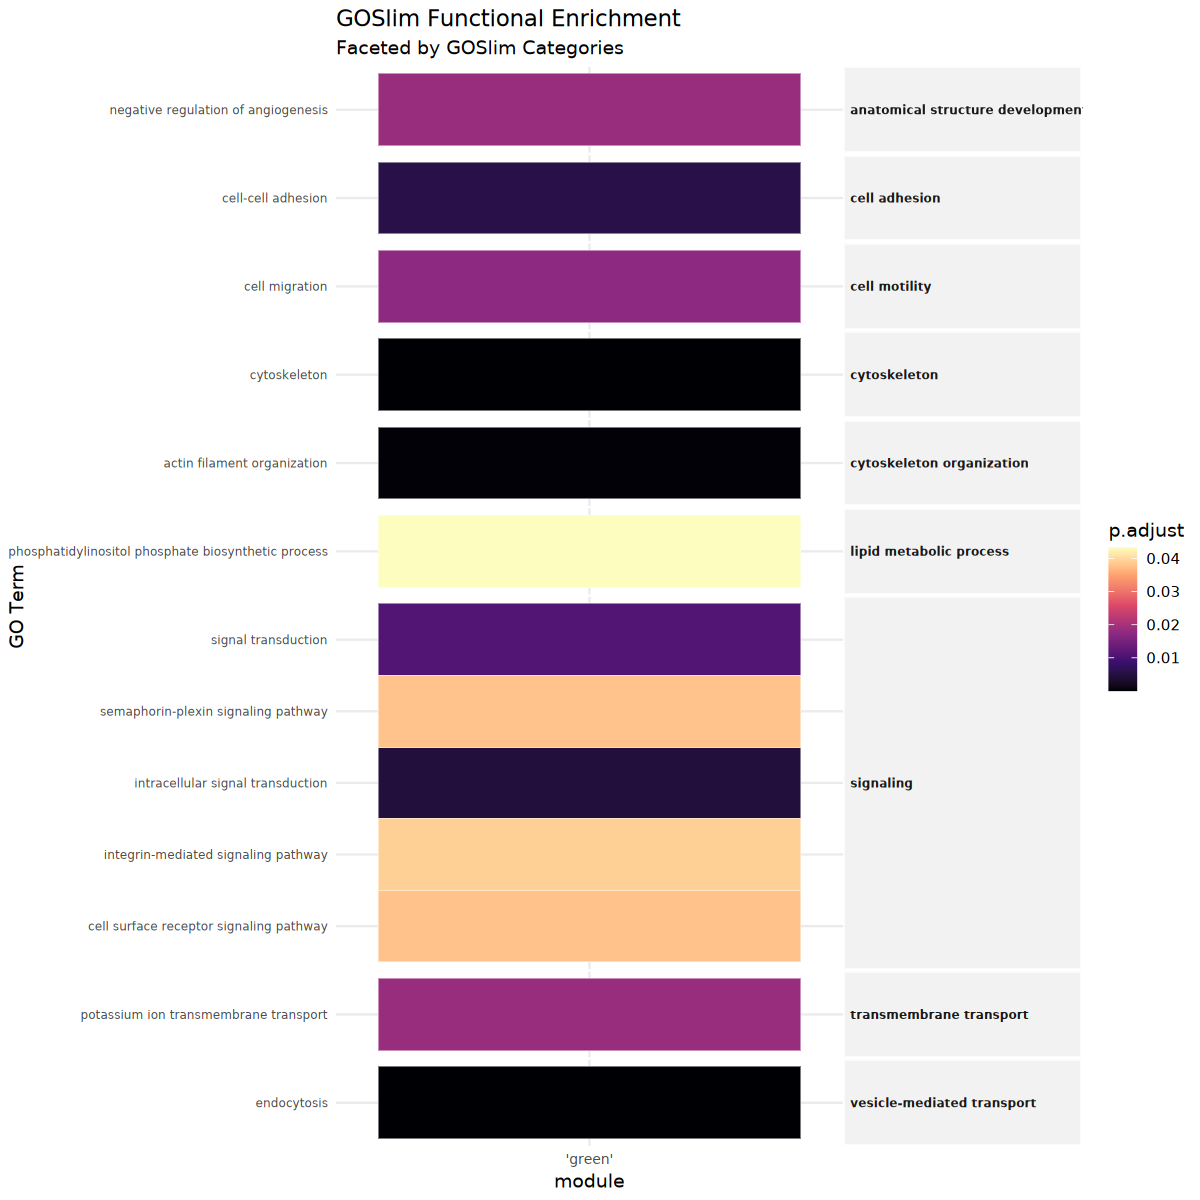

In [49]:
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(green_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

only two GO terms, but only one that mapped to a parent term (?) - metabolism

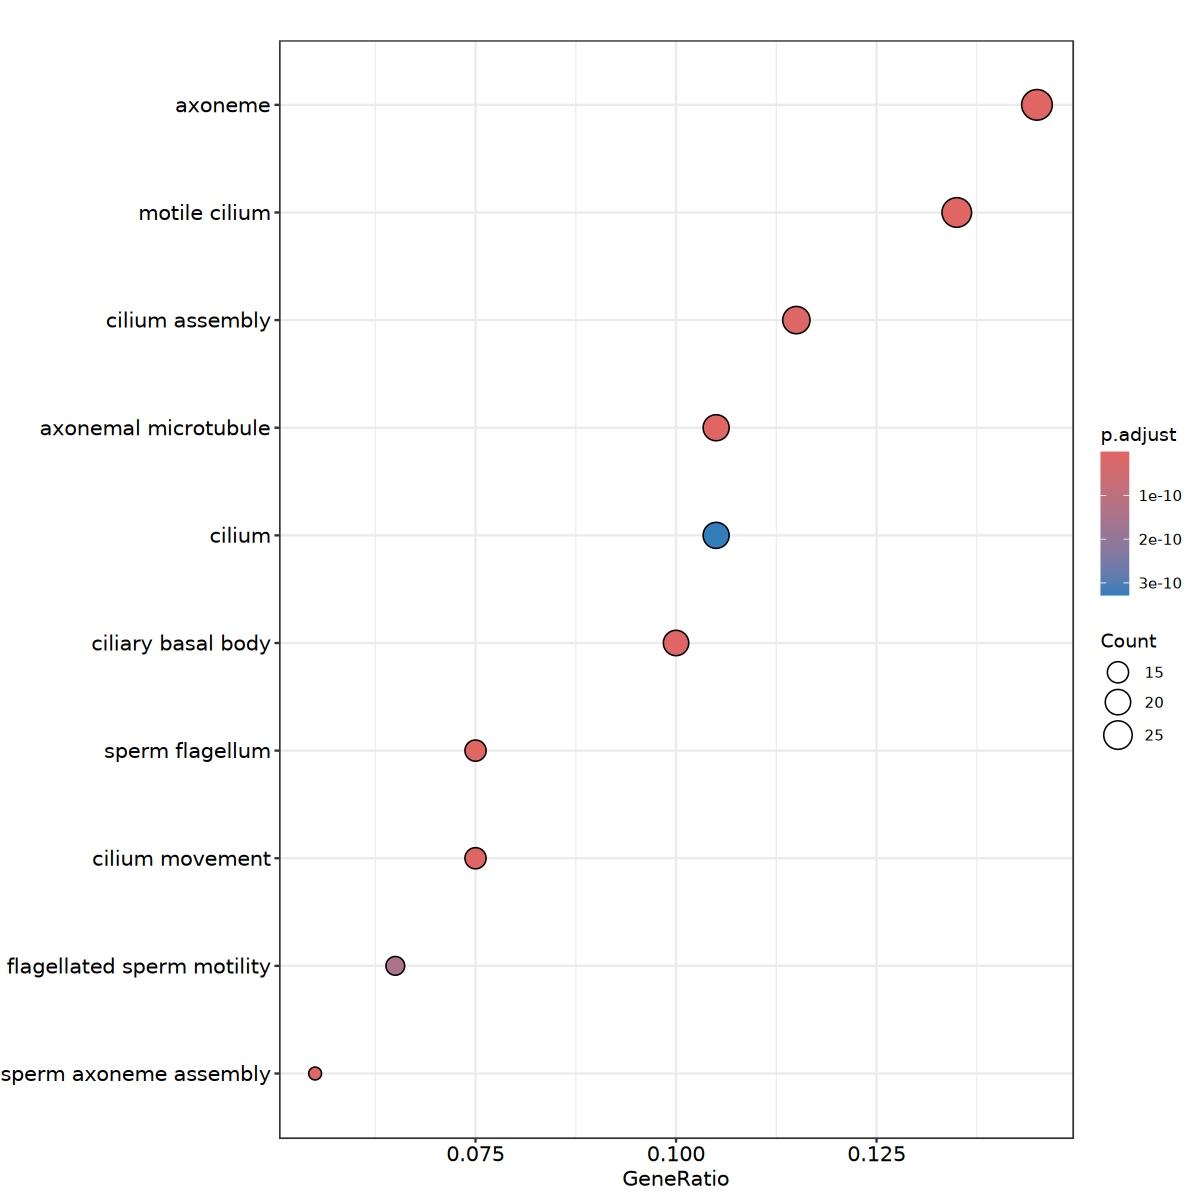

In [18]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "cyan") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
cyan_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

look for parent terms/bin GO terms to broader categories

In [19]:
cyan_mapped <- cyan_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
cyan_final <- cyan_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'cyan'")

head(cyan_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0003341,cilium movement,15/200,53/13421,8.897860e-16,8.435172e-14,7.249415e-14,LOC111103394/LOC111104160/LOC111108589/LOC111112623/LOC111118145/LOC111122642/LOC111123910/LOC111124887/LOC111127536/LOC111129512/LOC111129855/LOC111129936/LOC111134321/LOC111137096/LOC111137169,15,GO:0007018,microtubule-based movement,'cyan'
GO:0007288,sperm axoneme assembly,11/200,27/13421,6.467911e-14,4.379699e-12,3.764032e-12,LOC111101808/LOC111103594/LOC111112113/LOC111115421/LOC111120598/LOC111124004/LOC111124606/LOC111125001/LOC111129371/LOC111137096/LOC111137307,11,GO:0007010,cytoskeleton organization,'cyan'
GO:0060271,cilium assembly,23/200,219/13421,1.697559e-13,1.005804e-11,8.644151e-12,LOC111099093/LOC111103394/LOC111103594/LOC111104160/LOC111104435/LOC111107716/LOC111115421/LOC111115715/LOC111118129/LOC111118145/LOC111120729/LOC111122003/LOC111123910/LOC111125668/LOC111129466/LOC111129512/LOC111129936/LOC111130289/LOC111131840/LOC111134336/LOC111134864/LOC111135089/LOC111138059,23,GO:0044782,cilium organization,'cyan'
GO:0030317,flagellated sperm motility,13/200,59/13421,2.681954e-12,1.412496e-10,1.213937e-10,LOC111103394/LOC111104160/LOC111110920/LOC111112113/LOC111120729/LOC111120808/LOC111122642/LOC111124004/LOC111129371/LOC111131580/LOC111134864/LOC111137169/LOC111138334,13,GO:0007018,microtubule-based movement,'cyan'
GO:0005929,cilium,21/200,213/13421,6.967245e-12,3.284679e-10,2.822942e-10,LOC111103594/LOC111103618/LOC111103803/LOC111111551/LOC111112129/LOC111112623/LOC111115715/LOC111118045/LOC111118145/LOC111122642/LOC111122798/LOC111125428/LOC111126154/LOC111129376/LOC111129377/LOC111129466/LOC111129936/LOC111131840/LOC111135560/LOC111138059/LOC111138334,21,GO:0005929,cilium,'cyan'
GO:0060294,cilium movement involved in cell motility,9/200,21/13421,7.622673e-12,3.284679e-10,2.822942e-10,LOC111101813/LOC111107716/LOC111120563/LOC111120729/LOC111121573/LOC111129936/LOC111134864/LOC111135089/LOC111138334,9,GO:0007018,microtubule-based movement,'cyan'


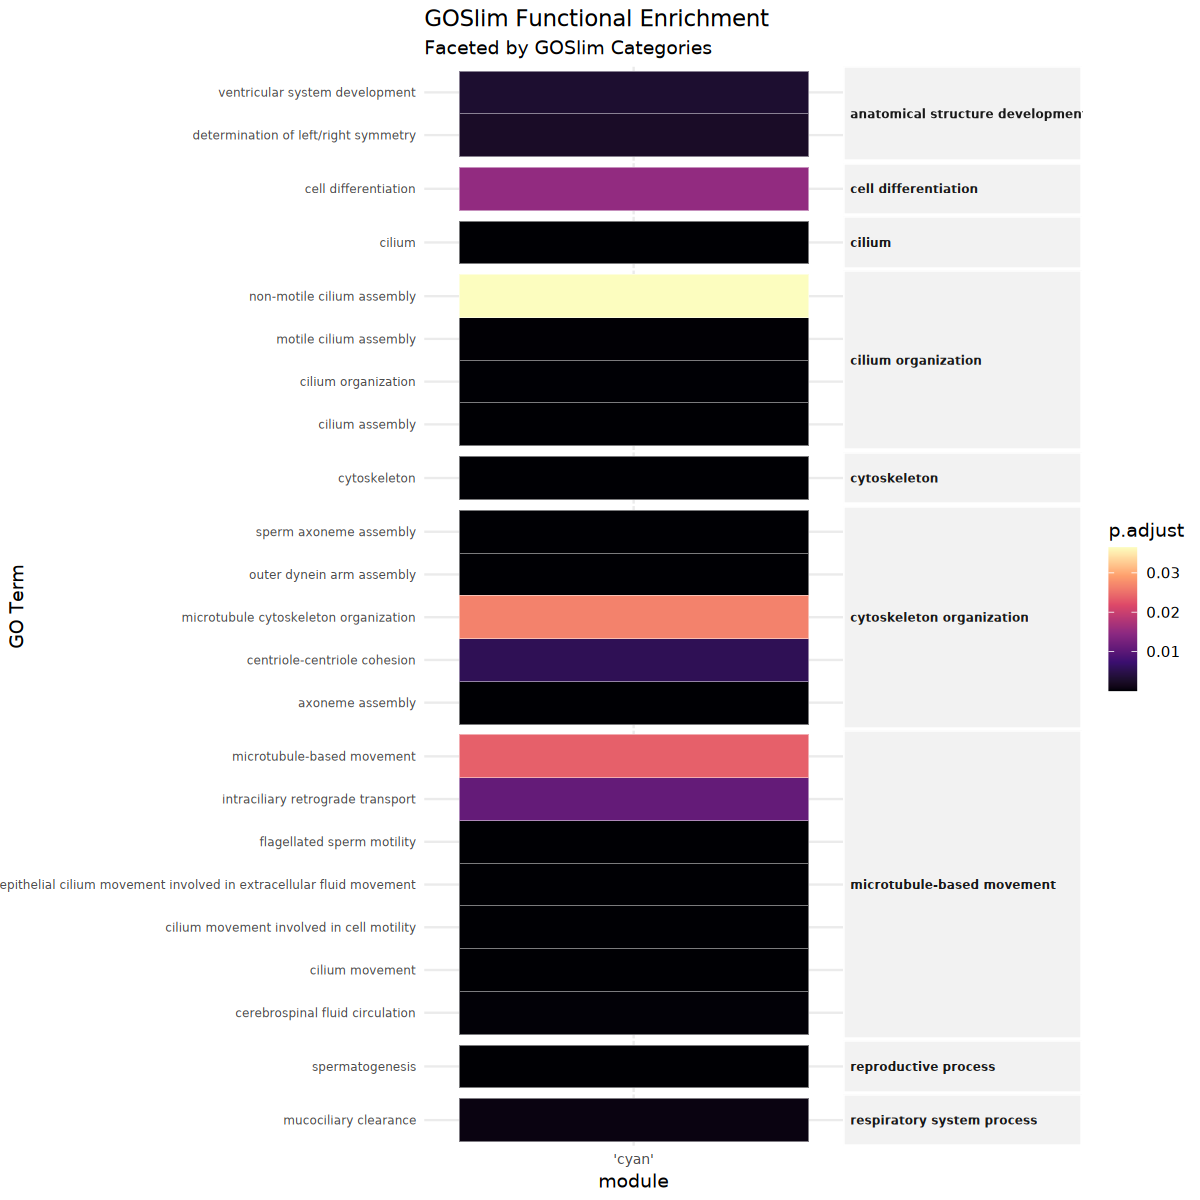

In [20]:
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(cyan_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

this cyan module is mainly involved in cytoskeleton, cilium - structural development

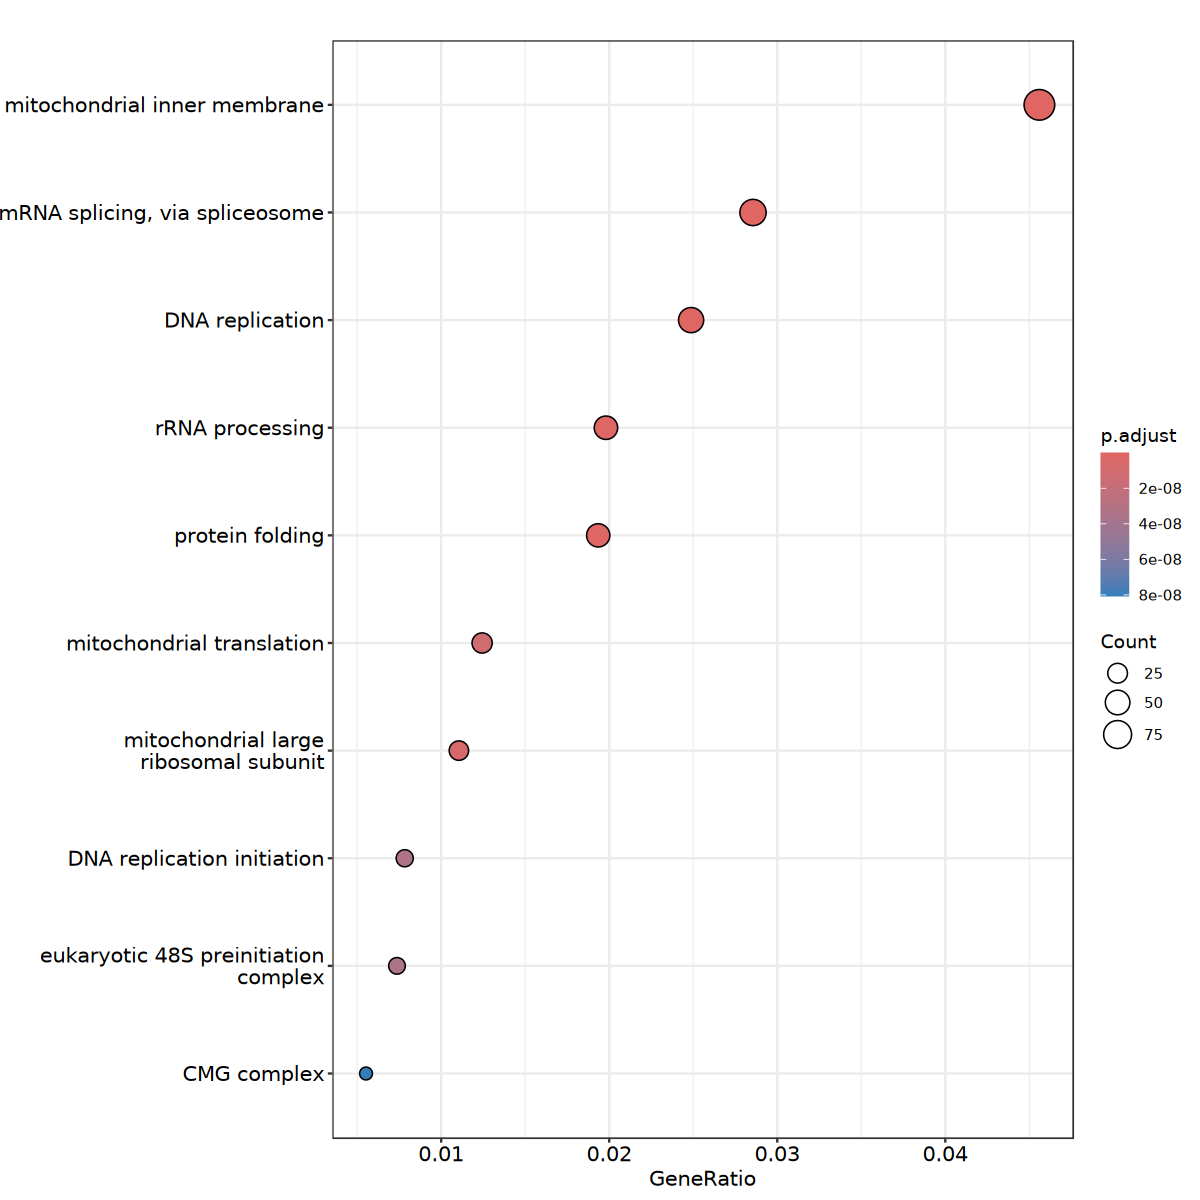

In [21]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "yellow") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
yellow_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

look for parent terms/bin GO terms to broader categories

In [22]:
yellow_mapped <- yellow_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
yellow_final <- yellow_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'yellow'")

head(yellow_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0000398,"mRNA splicing, via spliceosome",62/2171,134/13421,2.292786e-16,2.958840e-13,2.762203e-13,LOC111101512/LOC111102762/LOC111102822/LOC111103914/LOC111104149/LOC111105896/LOC111106208/LOC111106300/LOC111106645/LOC111107715/LOC111108450/LOC111108517/LOC111108640/LOC111108729/LOC111111061/LOC111115058/LOC111118194/LOC111118539/LOC111118582/LOC111119055/LOC111119756/LOC111120267/LOC111120515/LOC111120541/LOC111120794/LOC111120828/LOC111120984/LOC111121008/LOC111121337/LOC111121481/LOC111122102/LOC111122502/LOC111122650/LOC111125507/LOC111126498/LOC111126553/LOC111126802/LOC111128756/LOC111129820/LOC111130068/LOC111130237/LOC111131012/LOC111131375/LOC111131404/LOC111132304/LOC111132305/LOC111132626/LOC111133226/LOC111134475/LOC111134667/LOC111134756/LOC111134942/LOC111135060/LOC111135285/LOC111135387/LOC111135499/LOC111136408/LOC111136413/LOC111136440/LOC111136607/LOC111138363/LOC111138391,62,GO:0016071,mRNA metabolic process,'yellow'
GO:0006260,DNA replication,54/2171,112/13421,2.189622e-15,1.883804e-12,1.758612e-12,LOC111100201/LOC111102289/LOC111102580/LOC111102843/LOC111103940/LOC111103948/LOC111104183/LOC111104642/LOC111106945/LOC111107764/LOC111108505/LOC111108617/LOC111109808/LOC111112959/LOC111118262/LOC111118358/LOC111120673/LOC111120775/LOC111120810/LOC111120878/LOC111120888/LOC111120910/LOC111121113/LOC111121171/LOC111121347/LOC111121435/LOC111122245/LOC111122251/LOC111122440/LOC111122897/LOC111123010/LOC111123065/LOC111124294/LOC111125562/LOC111126776/LOC111127828/LOC111128572/LOC111130057/LOC111130346/LOC111130510/LOC111130531/LOC111130645/LOC111131048/LOC111131721/LOC111132235/LOC111132874/LOC111133827/LOC111133987/LOC111134654/LOC111136551/LOC111137179/LOC111137485/LOC111137577/LOC111138461,54,GO:0006260,DNA replication,'yellow'
GO:0006364,rRNA processing,43/2171,90/13421,2.299277e-12,1.381203e-09,1.289412e-09,LOC111099808/LOC111103448/LOC111103981/LOC111104266/LOC111106001/LOC111107584/LOC111108641/LOC111108699/LOC111108747/LOC111110750/LOC111116137/LOC111118140/LOC111118739/LOC111119222/LOC111120087/LOC111120384/LOC111120863/LOC111120892/LOC111121130/LOC111121216/LOC111121481/LOC111121772/LOC111121958/LOC111123045/LOC111123074/LOC111123477/LOC111125875/LOC111127475/LOC111128527/LOC111128756/LOC111129891/LOC111130461/LOC111130503/LOC111132118/LOC111132132/LOC111135058/LOC111135802/LOC111136635/LOC111136875/LOC111137070/LOC111137638/LOC111138309/LOC111138435,43,GO:0042254,ribosome biogenesis,'yellow'
GO:0006457,protein folding,42/2171,87/13421,2.675713e-12,1.381203e-09,1.289412e-09,LOC111100222/LOC111100813/LOC111101057/LOC111102092/LOC111104099/LOC111106300/LOC111107057/LOC111107136/LOC111112302/LOC111113446/LOC111114578/LOC111114582/LOC111115433/LOC111119711/LOC111120649/LOC111120828/LOC111121008/LOC111121532/LOC111121539/LOC111122969/LOC111123621/LOC111124122/LOC111124701/LOC111125459/LOC111125815/LOC111125951/LOC111125995/LOC111127231/LOC111127921/LOC111128347/LOC111128544/LOC111128632/LOC111128939/LOC111130072/LOC111130732/LOC111130879/LOC111131116/LOC111131153/LOC111134667/LOC111136916/LOC111137548/LOC111138167,42,GO:0006457,protein folding,'yellow'
GO:0032543,mitochondrial translation,27/2171,45/13421,3.210064e-11,1.183597e-08,1.104938e-08,LOC111103991/LOC111104044/LOC111104114/LOC111104483/LOC111105261/LOC111107427/LOC111108044/LOC111125723/LOC111125796/LOC111126349/LOC111126431/LOC111127785/LOC111128022/LOC111128321/LOC111130233/LOC111130939/LOC111131333/LOC111133190/LOC111134635/LOC111136487/LOC111136749/LOC111136890/LOC111137006/LOC111137070/LOC111137581/LOC111137692/LOC111137898,27,GO:0140053,mitochondrial gene expression,'yellow'
GO:0006270,DNA replication initiation,17/2171,21/13421,1.045557e-10,3.373228e-08,3.149052e-08,LOC111103623/LOC111105728/LOC111109564/LOC111121347/LOC111122245/LOC111123110/LOC111124297/LOC111126192/LOC11113

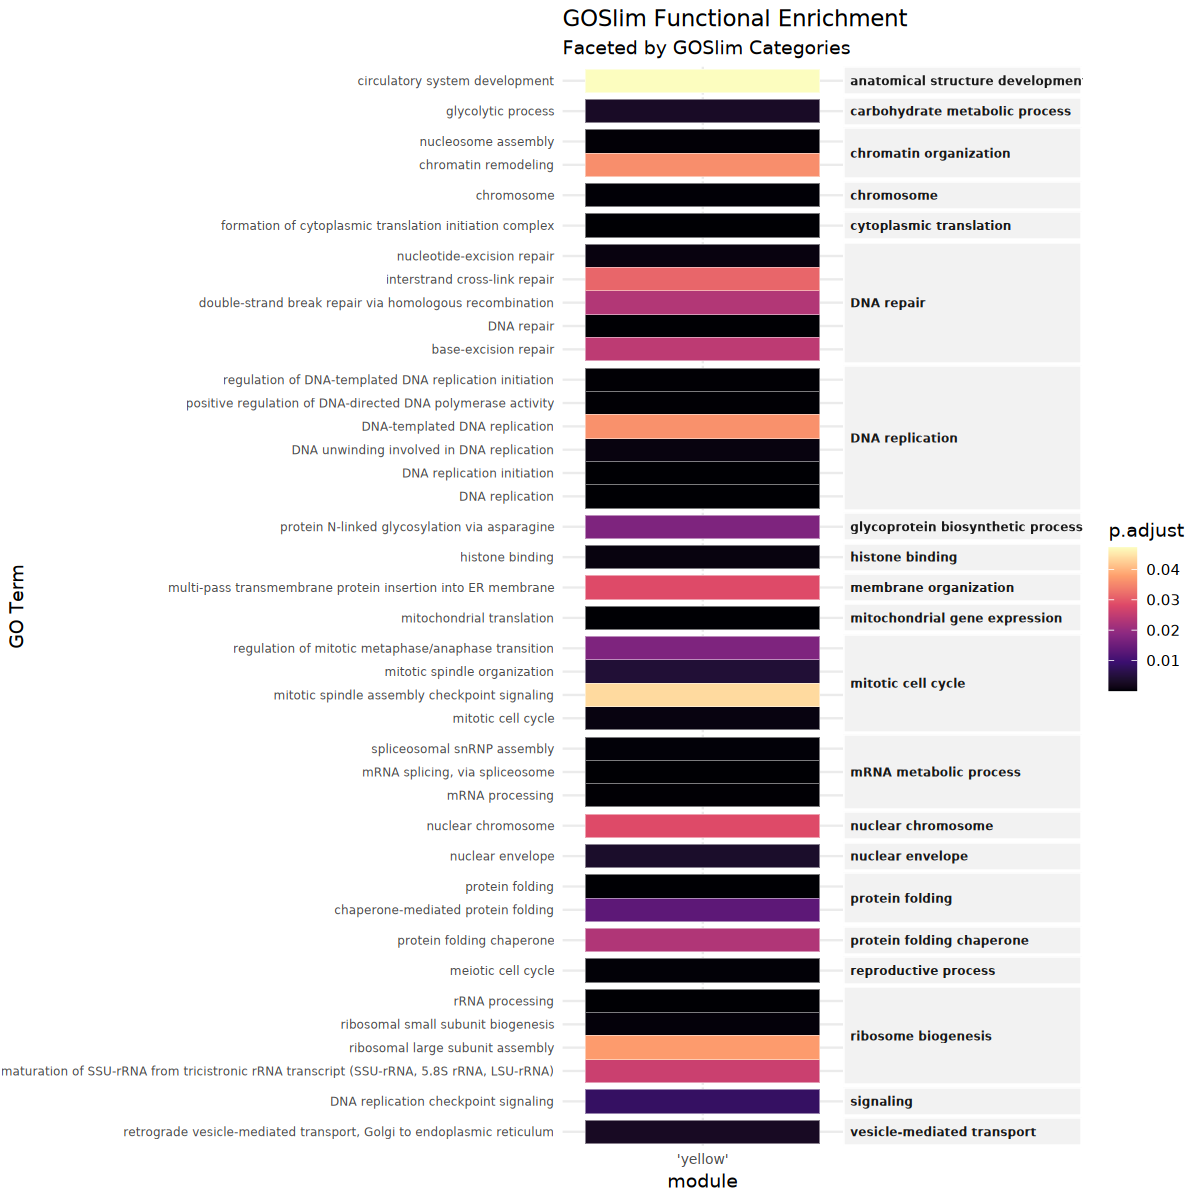

In [23]:
options(repr.plot.width = 10, repr.plot.height = 10)

ggplot(yellow_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

looks like a lot of DNA repair and replication - lot of epigenetic processes like chromatin organization and histone binding

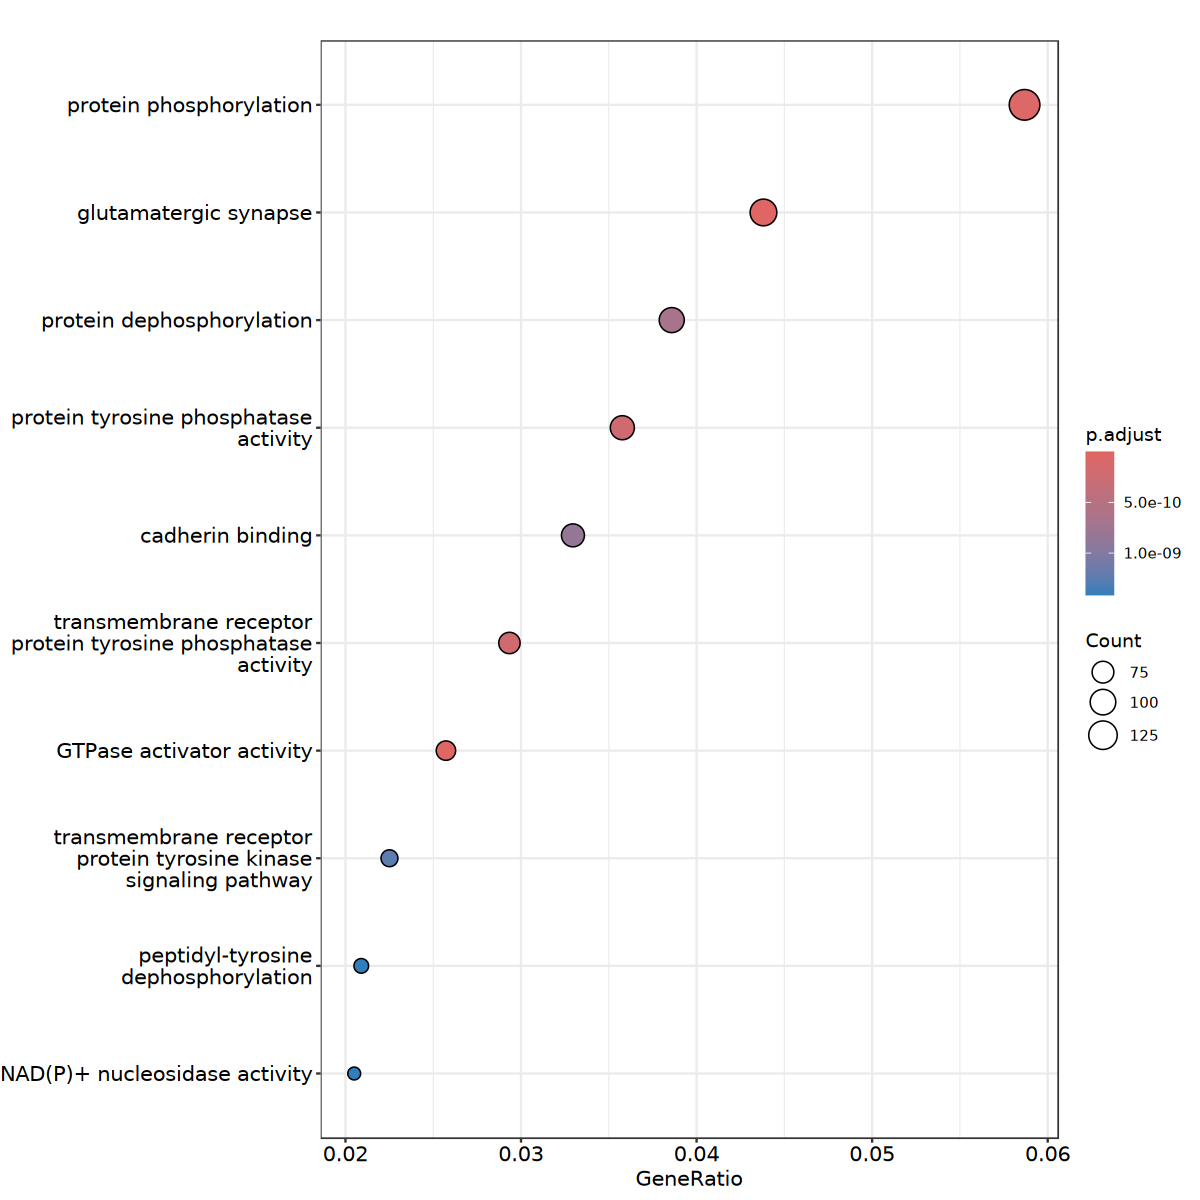

In [24]:
target_genes <- geneInfo %>%
  filter(ModuleColor == "blue") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
blue_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

look for parent terms/bin GO terms to broader categories

In [25]:
blue_mapped <- blue_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
blue_final <- blue_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'blue'")

head(blue_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0007169,transmembrane receptor protein tyrosine kinase signaling pathway,56/2488,122/13421,3.576002e-12,1.243555e-09,1.042687e-09,LOC111103722/LOC111106539/LOC111107445/LOC111107549/LOC111107550/LOC111109191/LOC111109831/LOC111110330/LOC111110390/LOC111111946/LOC111111948/LOC111112366/LOC111112739/LOC111113138/LOC111113167/LOC111113168/LOC111113170/LOC111113179/LOC111113207/LOC111113430/LOC111113685/LOC111114475/LOC111114500/LOC111114502/LOC111114722/LOC111114723/LOC111115259/LOC111115262/LOC111115264/LOC111116053/LOC111116632/LOC111117321/LOC111117327/LOC111117345/LOC111117469/LOC111117666/LOC111118172/LOC111118720/LOC111119050/LOC111119192/LOC111119718/LOC111119719/LOC111119769/LOC111119805/LOC111120008/LOC111120801/LOC111121258/LOC111123772/LOC111124011/LOC111125677/LOC111129309/LOC111129741/LOC111130114/LOC111134024/LOC111134499/LOC111134583,56,GO:0023052,signaling,'blue'
GO:0035556,intracellular signal transduction,66/2488,161/13421,2.450948e-11,5.682114e-09,4.764299e-09,LOC111100277/LOC111100477/LOC111104269/LOC111104302/LOC111104335/LOC111105688/LOC111106022/LOC111107301/LOC111107545/LOC111107852/LOC111108129/LOC111108201/LOC111108281/LOC111109755/LOC111112350/LOC111112498/LOC111113262/LOC111113385/LOC111113387/LOC111114988/LOC111117024/LOC111119422/LOC111120341/LOC111120490/LOC111120610/LOC111120801/LOC111120974/LOC111121890/LOC111122172/LOC111122377/LOC111122823/LOC111123459/LOC111124889/LOC111125155/LOC111128016/LOC111128531/LOC111128535/LOC111128838/LOC111129169/LOC111129627/LOC111130017/LOC111130217/LOC111130271/LOC111130544/LOC111130581/LOC111130737/LOC111130774/LOC111131555/LOC111131687/LOC111131917/LOC111132955/LOC111133239/LOC111133328/LOC111134075/LOC111134230/LOC111134421/LOC111134515/LOC111134614/LOC111135114/LOC111135195/LOC111135231/LOC111135248/LOC111136514/LOC111136596/LOC111136638/LOC111137641,66,GO:0023052,signaling,'blue'
GO:0030336,negative regulation of cell migration,60/2488,148/13421,3.335892e-10,4.218387e-08,3.537003e-08,LOC111103722/LOC111103819/LOC111105828/LOC111107545/LOC111107549/LOC111107550/LOC111109191/LOC111110083/LOC111110347/LOC111110390/LOC111111946/LOC111111948/LOC111112366/LOC111112739/LOC111113061/LOC111113134/LOC111113138/LOC111113167/LOC111113168/LOC111113170/LOC111113179/LOC111113207/LOC111113430/LOC111113685/LOC111113736/LOC111113771/LOC111114475/LOC111114500/LOC111114502/LOC111114722/LOC111114723/LOC111115259/LOC111115262/LOC111115263/LOC111115264/LOC111116053/LOC111116632/LOC111117321/LOC111117327/LOC111117345/LOC111117469/LOC111117666/LOC111118172/LOC111118720/LOC111119192/LOC111119718/LOC111119719/LOC111119769/LOC111119805/LOC111120008/LOC111120167/LOC111121062/LOC111122145/LOC111122172/LOC111124952/LOC111125677/LOC111131682/LOC111134655/LOC111135949/LOC111138231,60,GO:0048870,cell motility,'blue'
GO:1904893,negative regulation of receptor signaling pathway via STAT,40/2488,82/13421,4.455056e-10,5.164153e-08,4.330002e-08,LOC111103722/LOC111107549/LOC111107550/LOC111109191/LOC111110390/LOC111111946/LOC111111948/LOC111112366/LOC111112739/LOC111113138/LOC111113167/LOC111113168/LOC111113170/LOC111113179/LOC111113207/LOC111113430/LOC111113685/LOC111114475/LOC111114500/LOC111114502/LOC111114722/LOC111114723/LOC111115259/LOC111115262/LOC111115264/LOC111116053/LOC111116632/LOC111117321/LOC111117327/LOC111117345/LOC111117469/LOC111117666/LOC111118172/LOC111118720/LOC111119718/LOC111119719/LOC111119769/LOC111119805/LOC111120008/LOC111125677,40,GO:0023052,signaling,'blue'
GO:0002224,toll-like receptor signaling pathway,47/2488,105/13421,5.511884e-10,6.133624e-08,5.142878e-08,LOC111102351/LOC111102510/LOC111102844/LOC111103127/LOC111103188/LOC111103359/LOC111104185/LOC111104237/LOC111104614/LOC111104635/LOC111105056/LOC111105749/LOC111106502/LOC111106939/LOC111106940/LOC111107840/LOC111108047/LOC111108209/LOC111108700/L

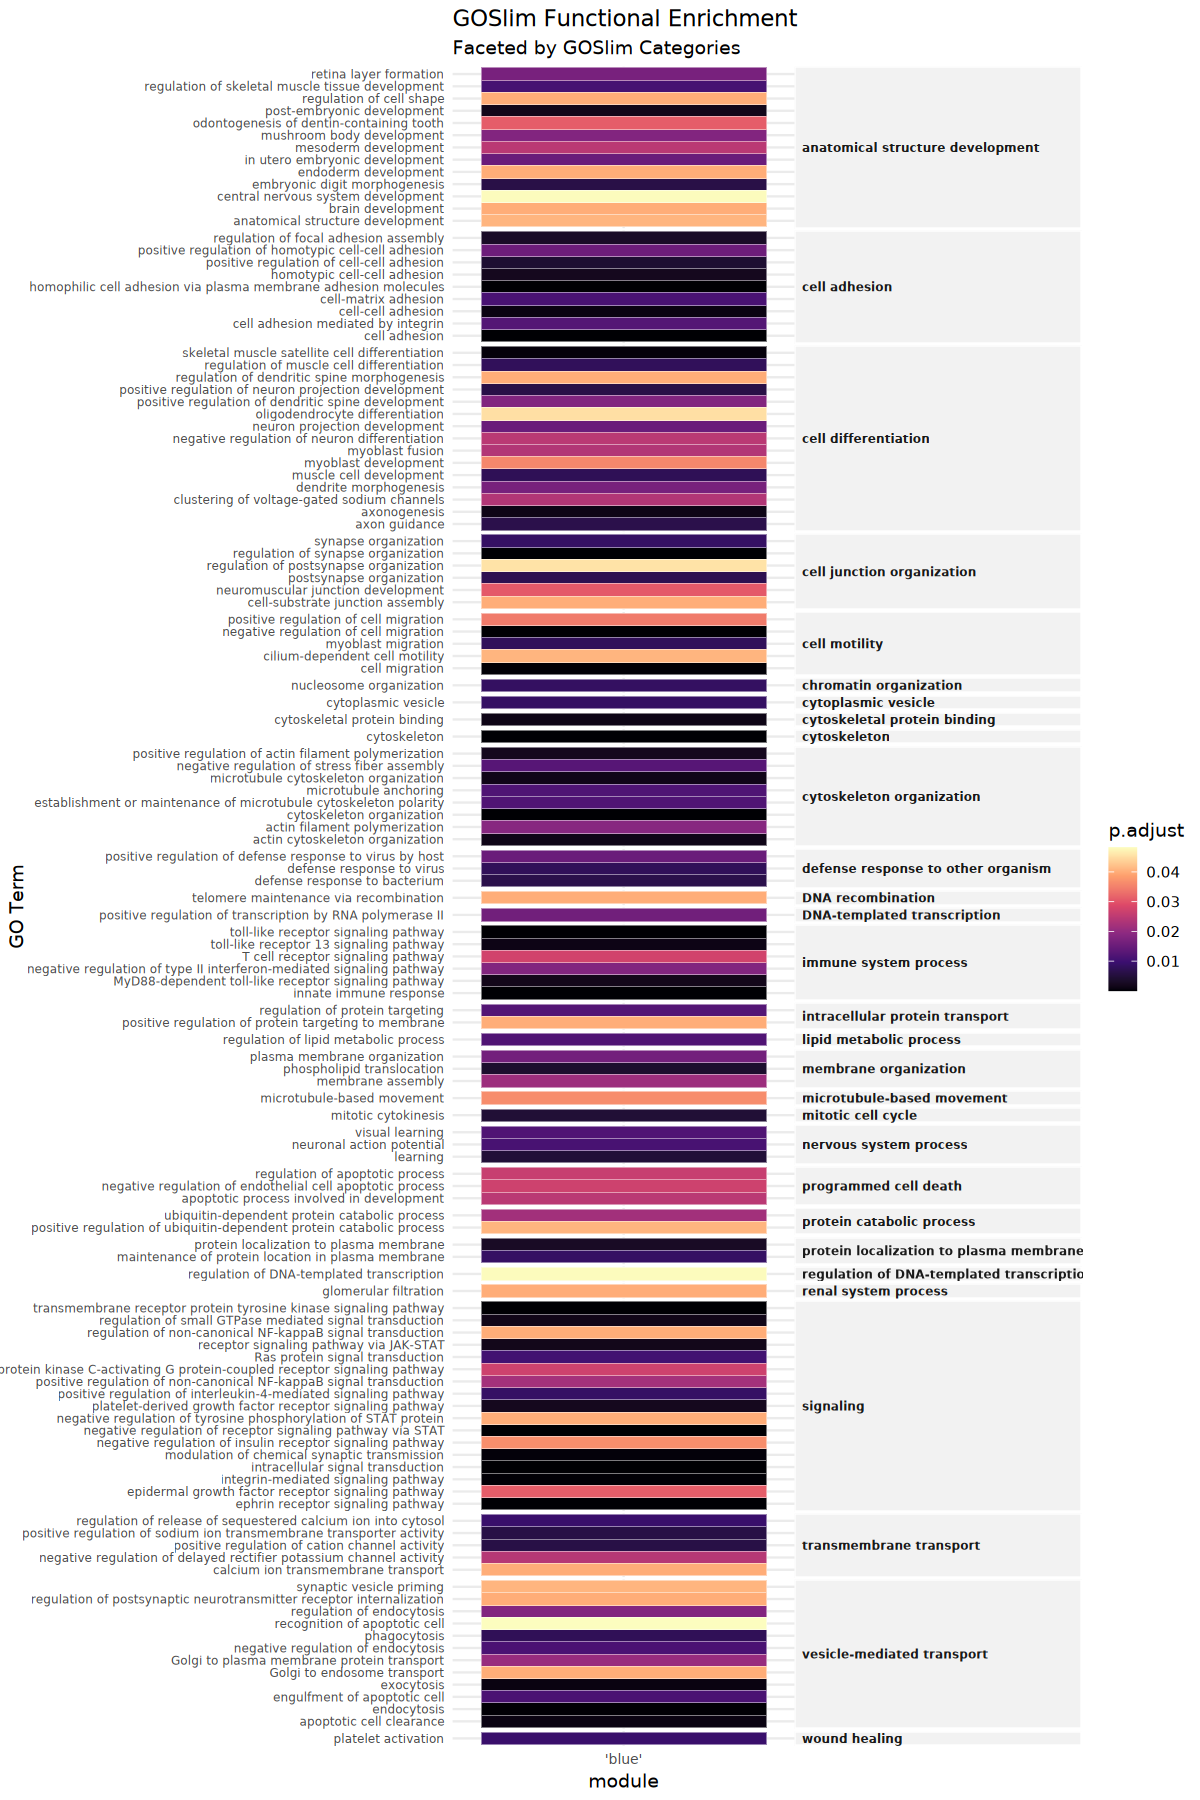

In [26]:
options(repr.plot.width = 10, repr.plot.height = 15)

ggplot(blue_final, aes(x = module, y = Description, fill = p.adjust)) +
  geom_tile(color = "white", size = 0.1) +
  # Grouping by GOSlim Category on the right side
  facet_grid(GOSlim_Bin ~ ., scales = "free_y", space = "free_y") +
  # Use a color scale that makes significant results "pop"
  scale_fill_viridis_c(option = "magma") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(size = 8),
    panel.spacing = unit(0.1, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by GOSlim Categories",
    y = "GO Term"
  )

more structural development - cell differentation, adhesion, development - lots of signaling and transport

wound healing and programmed cell death is interesting too - these genes tend to have higher expression in treatments warm and hypoxic (single stressors) and lower in control conditions

### salmon module
significantly correlated with downregulation in P2 cont

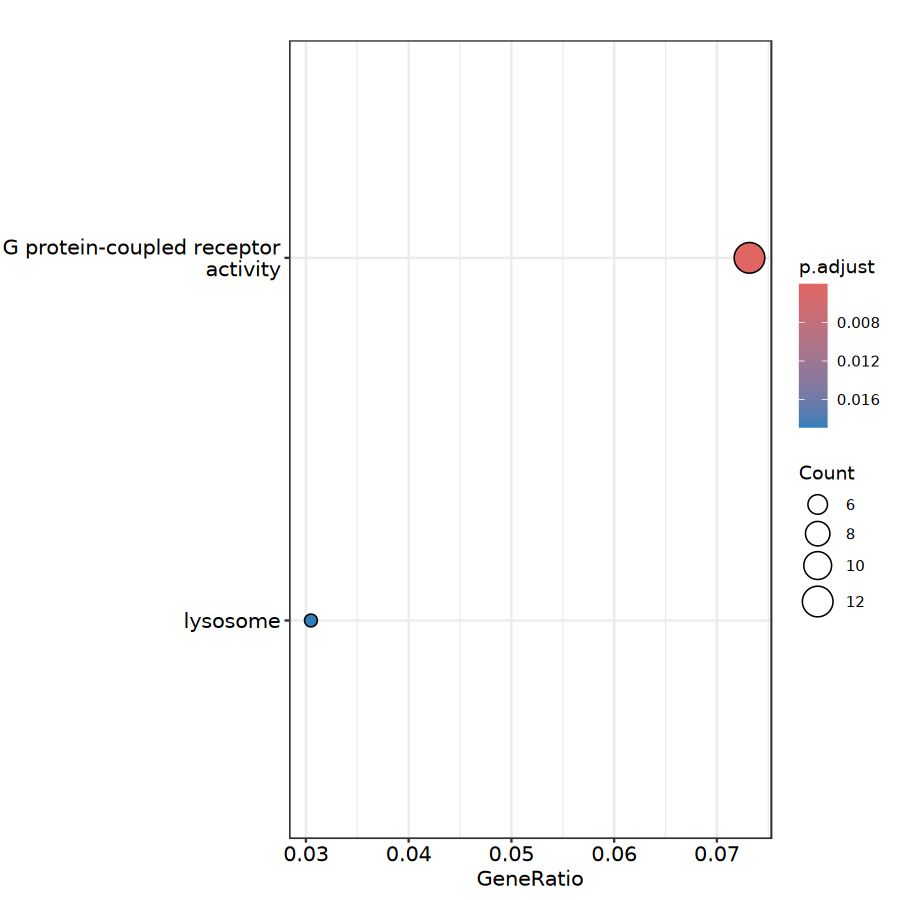

In [43]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

target_genes <- geneInfo %>%
  filter(ModuleColor == "salmon") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
salmon_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

- lysosome - the organism's waste disposal system
- G protein-coupled receptor activity - largest family of cell-surface receptors - primary sensory and messaging inbox

look for parent terms/bin GO terms to broader categories

In [45]:
salmon_mapped <- salmon_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
salmon_final <- salmon_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'salmon'")

head(salmon_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0005764,lysosome,5/164,33/9340,0.0002503416,0.01890079,0.01791919,LOC111106777/LOC111106925/LOC111121485/LOC111121750/LOC111127014,5,GO:0005764,lysosome,'salmon'


### magenta module
significantly correlated with upregulation in P2 treatment (and P2 temp and DO; specifically upreg in Both and downreg in Cont)

similar to the salmon module but correlated slightly less

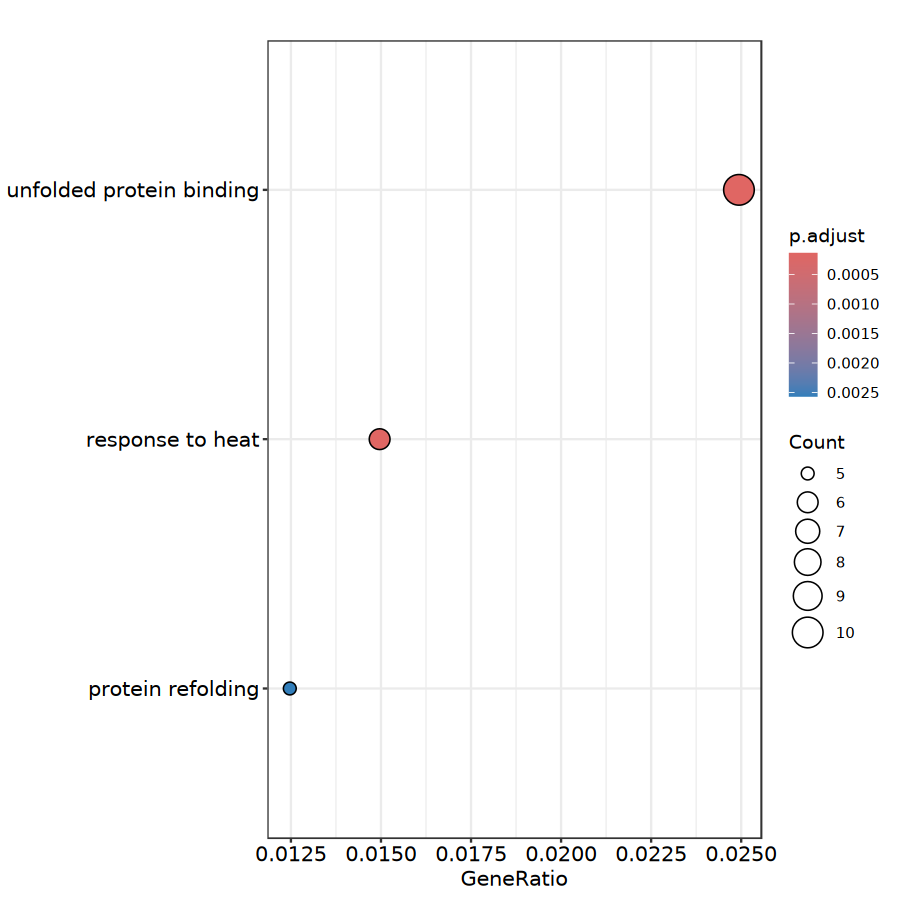

In [44]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

target_genes <- geneInfo %>%
  filter(ModuleColor == "magenta") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
magenta_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

In [61]:
magenta_mapped <- magenta_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
magenta_final <- magenta_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'magenta'")

head(magenta_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0042026,protein refolding,5/401,10/9340,2.999041e-05,0.002569179,0.002462371,LOC111103416/LOC111107270/LOC111119044/LOC111135749/LOC144618159,5,GO:0006457,protein folding,'magenta'


### purple module
significantly correlated with P2 temp - downreg in warm and upreg in ambient 

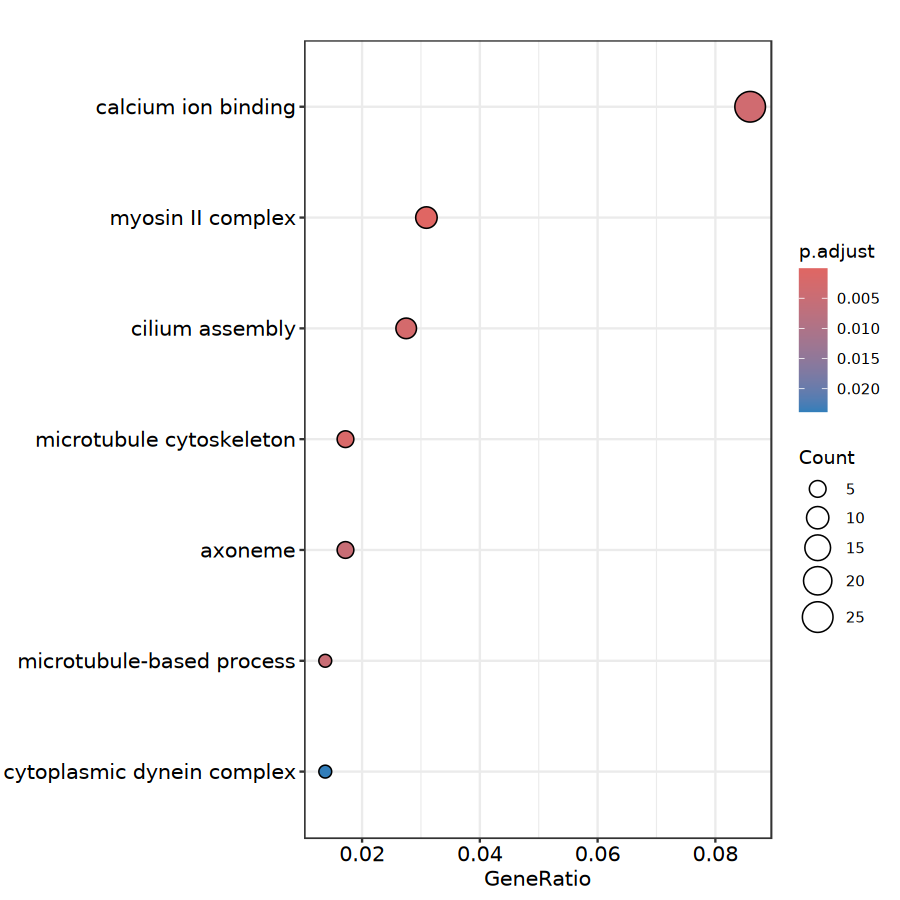

In [57]:
options(repr.plot.height = 7.5, repr.plot.width = 7.5)

# purple 
target_genes <- geneInfo %>%
  filter(ModuleColor == "purple") %>%
  pull(Gene)

# Run the custom enrichment
ego_custom <- enricher(gene = target_genes,
                       universe = universal_genes$gene,
                       TERM2NAME = term2name,
                       TERM2GENE = term2gene,
                       pvalueCutoff = 0.05)

# make df
purple_res <- as.data.frame(ego_custom)

# View results
dotplot(ego_custom)

In [58]:
purple_mapped <- purple_res %>%
  # Process each row's ID individually
  rowwise() %>%
  # use function from earlier to map parent term to GO ID
  mutate(SlimID = find_slim_parent(ID, target_slim_ids)) %>% 
  ungroup() %>%
  # Join with lookup table to get 'GOSlim_Bin'
  left_join(slim_lookup, by = "SlimID")

# Remove terms that didn't map to a slim category if desired
purple_final <- purple_mapped %>%
  filter(!is.na(GOSlim_Bin)) %>%
mutate(module = "'purple'")

head(purple_final)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>
GO:0060271,cilium assembly,8/291,43/9340,4.523511e-05,0.002623637,0.002380795,LOC111106953/LOC111107237/LOC111118797/LOC111120729/LOC111121573/LOC111130289/LOC111135089/LOC111136209,8,GO:0044782,cilium organization,'purple'


## combining these:

In [62]:
# combine all sig. modules GO results
module.GO <- rbind(brown_final, green_final, salmon_final, magenta_final, purple_final)

In [69]:
# add whether the module was sig. correlated with phase 1 or phase 2 treatments/traits
 module.GO <- module.GO %>%
 mutate(sigCor_phase = 'phase2')

# check it worked
head(module.GO)

ID,Description,GeneRatio,BgRatio,pvalue,p.adjust,qvalue,geneID,Count,SlimID,GOSlim_Bin,module,sigCor_phase
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>
GO:0003723,RNA binding,72/1266,223/9340,2.798794e-13,1.038352e-10,8.632069e-11,LOC111099922/LOC111103914/LOC111104149/LOC111105897/LOC111107584/LOC111111061/LOC111111718/LOC111112016/LOC111112550/LOC111112585/LOC111112733/LOC111113059/LOC111113115/LOC111116966/LOC111117964/LOC111118049/LOC111118069/LOC111118140/LOC111118362/LOC111118539/LOC111118739/LOC111118852/LOC111119023/LOC111119055/LOC111120664/LOC111120828/LOC111120891/LOC111120897/LOC111120899/LOC111121238/LOC111123381/LOC111125369/LOC111126802/LOC111127420/LOC111128022/LOC111128711/LOC111128922/LOC111129406/LOC111129496/LOC111129712/LOC111129853/LOC111130348/LOC111130461/LOC111130503/LOC111130565/LOC111130828/LOC111132975/LOC111133148/LOC111133159/LOC111133382/LOC111133458/LOC111133504/LOC111134482/LOC111134501/LOC111134942/LOC111135336/LOC111135391/LOC111135640/LOC111136320/LOC111136413/LOC111138305/LOC111138309/LOC111138363/LOC144618177/LOC144619028/LOC144622099/LOC144622109/LOC144622290/LOC144623848/LOC144625443/LOC144625869/LOC144626230,72,GO:0003723,RNA binding,'brown',phase2
GO:0005730,nucleolus,29/1266,61/9340,1.380650e-10,2.561105e-08,2.129107e-08,LOC111103620/LOC111110332/LOC111118069/LOC111118739/LOC111118852/LOC111120892/LOC111120897/LOC111121751/LOC111123381/LOC111125438/LOC111127822/LOC111128527/LOC111129839/LOC111129891/LOC111130371/LOC111130503/LOC111132132/LOC111133059/LOC111133335/LOC111133926/LOC111134594/LOC111134754/LOC111135336/LOC111135538/LOC111135565/LOC111135974/LOC111136220/LOC144620872/LOC144626880,29,GO:0005730,nucleolus,'brown',phase2
GO:0005739,mitochondrion,65/1266,230/9340,2.328753e-09,2.879891e-07,2.394122e-07,LOC111099882/LOC111100042/LOC111100768/LOC111103557/LOC111103813/LOC111104191/LOC111104314/LOC111104353/LOC111104483/LOC111105388/LOC111105692/LOC111105866/LOC111105912/LOC111107126/LOC111114229/LOC111115725/LOC111117758/LOC111118028/LOC111118056/LOC111118131/LOC111118249/LOC111120704/LOC111120825/LOC111120828/LOC111120899/LOC111121154/LOC111121171/LOC111121268/LOC111121506/LOC111125126/LOC111127195/LOC111127785/LOC111127815/LOC111127891/LOC111127947/LOC111127953/LOC111128143/LOC111128270/LOC111128646/LOC111129097/LOC111129316/LOC111129959/LOC111130025/LOC111130538/LOC111130742/LOC111132130/LOC111132779/LOC111133477/LOC111133661/LOC111133858/LOC111134378/LOC111134424/LOC111134852/LOC111135360/LOC111135445/LOC111136048/LOC111136154/LOC111136221/LOC111136260/LOC111138406/LOC144619508/LOC144622705/LOC144622927/LOC144626864/LOC144627595,65,GO:0005739,mitochondrion,'brown',phase2
GO:0000398,"mRNA splicing, via spliceosome",19/1266,36/9340,2.465774e-08,2.287005e-06,1.901242e-06,LOC111099922/LOC111103914/LOC111104149/LOC111106006/LOC111106208/LOC111107428/LOC111111061/LOC111118194/LOC111118582/LOC111119018/LOC111119055/LOC111121238/LOC111134756/LOC111135499/LOC111136320/LOC111138363/LOC111138391/LOC144619426/LOC144622290,19,GO:0016071,mRNA metabolic process,'brown',phase2
GO:0000724,double-strand break repair via homologous recombination,19/1266,43/9340,8.922336e-07,3.677985e-05,3.057596e-05,LOC111100611/LOC111103091/LOC111103948/LOC111110332/LOC111116012/LOC111120888/LOC111121716/LOC111128268/LOC111130258/LOC111130364/LOC111130622/LOC111130645/LOC111135650/LOC111136054/LOC144623221/LOC144623312/LOC144625441/LOC144625895/LOC144627387,19,GO:0006281,DNA repair,'brown',phase2
GO:0006457,protein folding,16/1266,34/9340,2.348111e-06,8.711492e-05,7.242069e-05,LOC111100668/LOC111104099/LOC111106300/LOC111107136/LOC111113446/LOC111120649/LOC111120828/LOC111121532/LOC111121539/LOC111125459/LOC111128545/LOC111128611/LOC111128632/LOC111128939/LOC111130072/LOC111134667,16,GO:0006457,protein folding,'brown',phase2


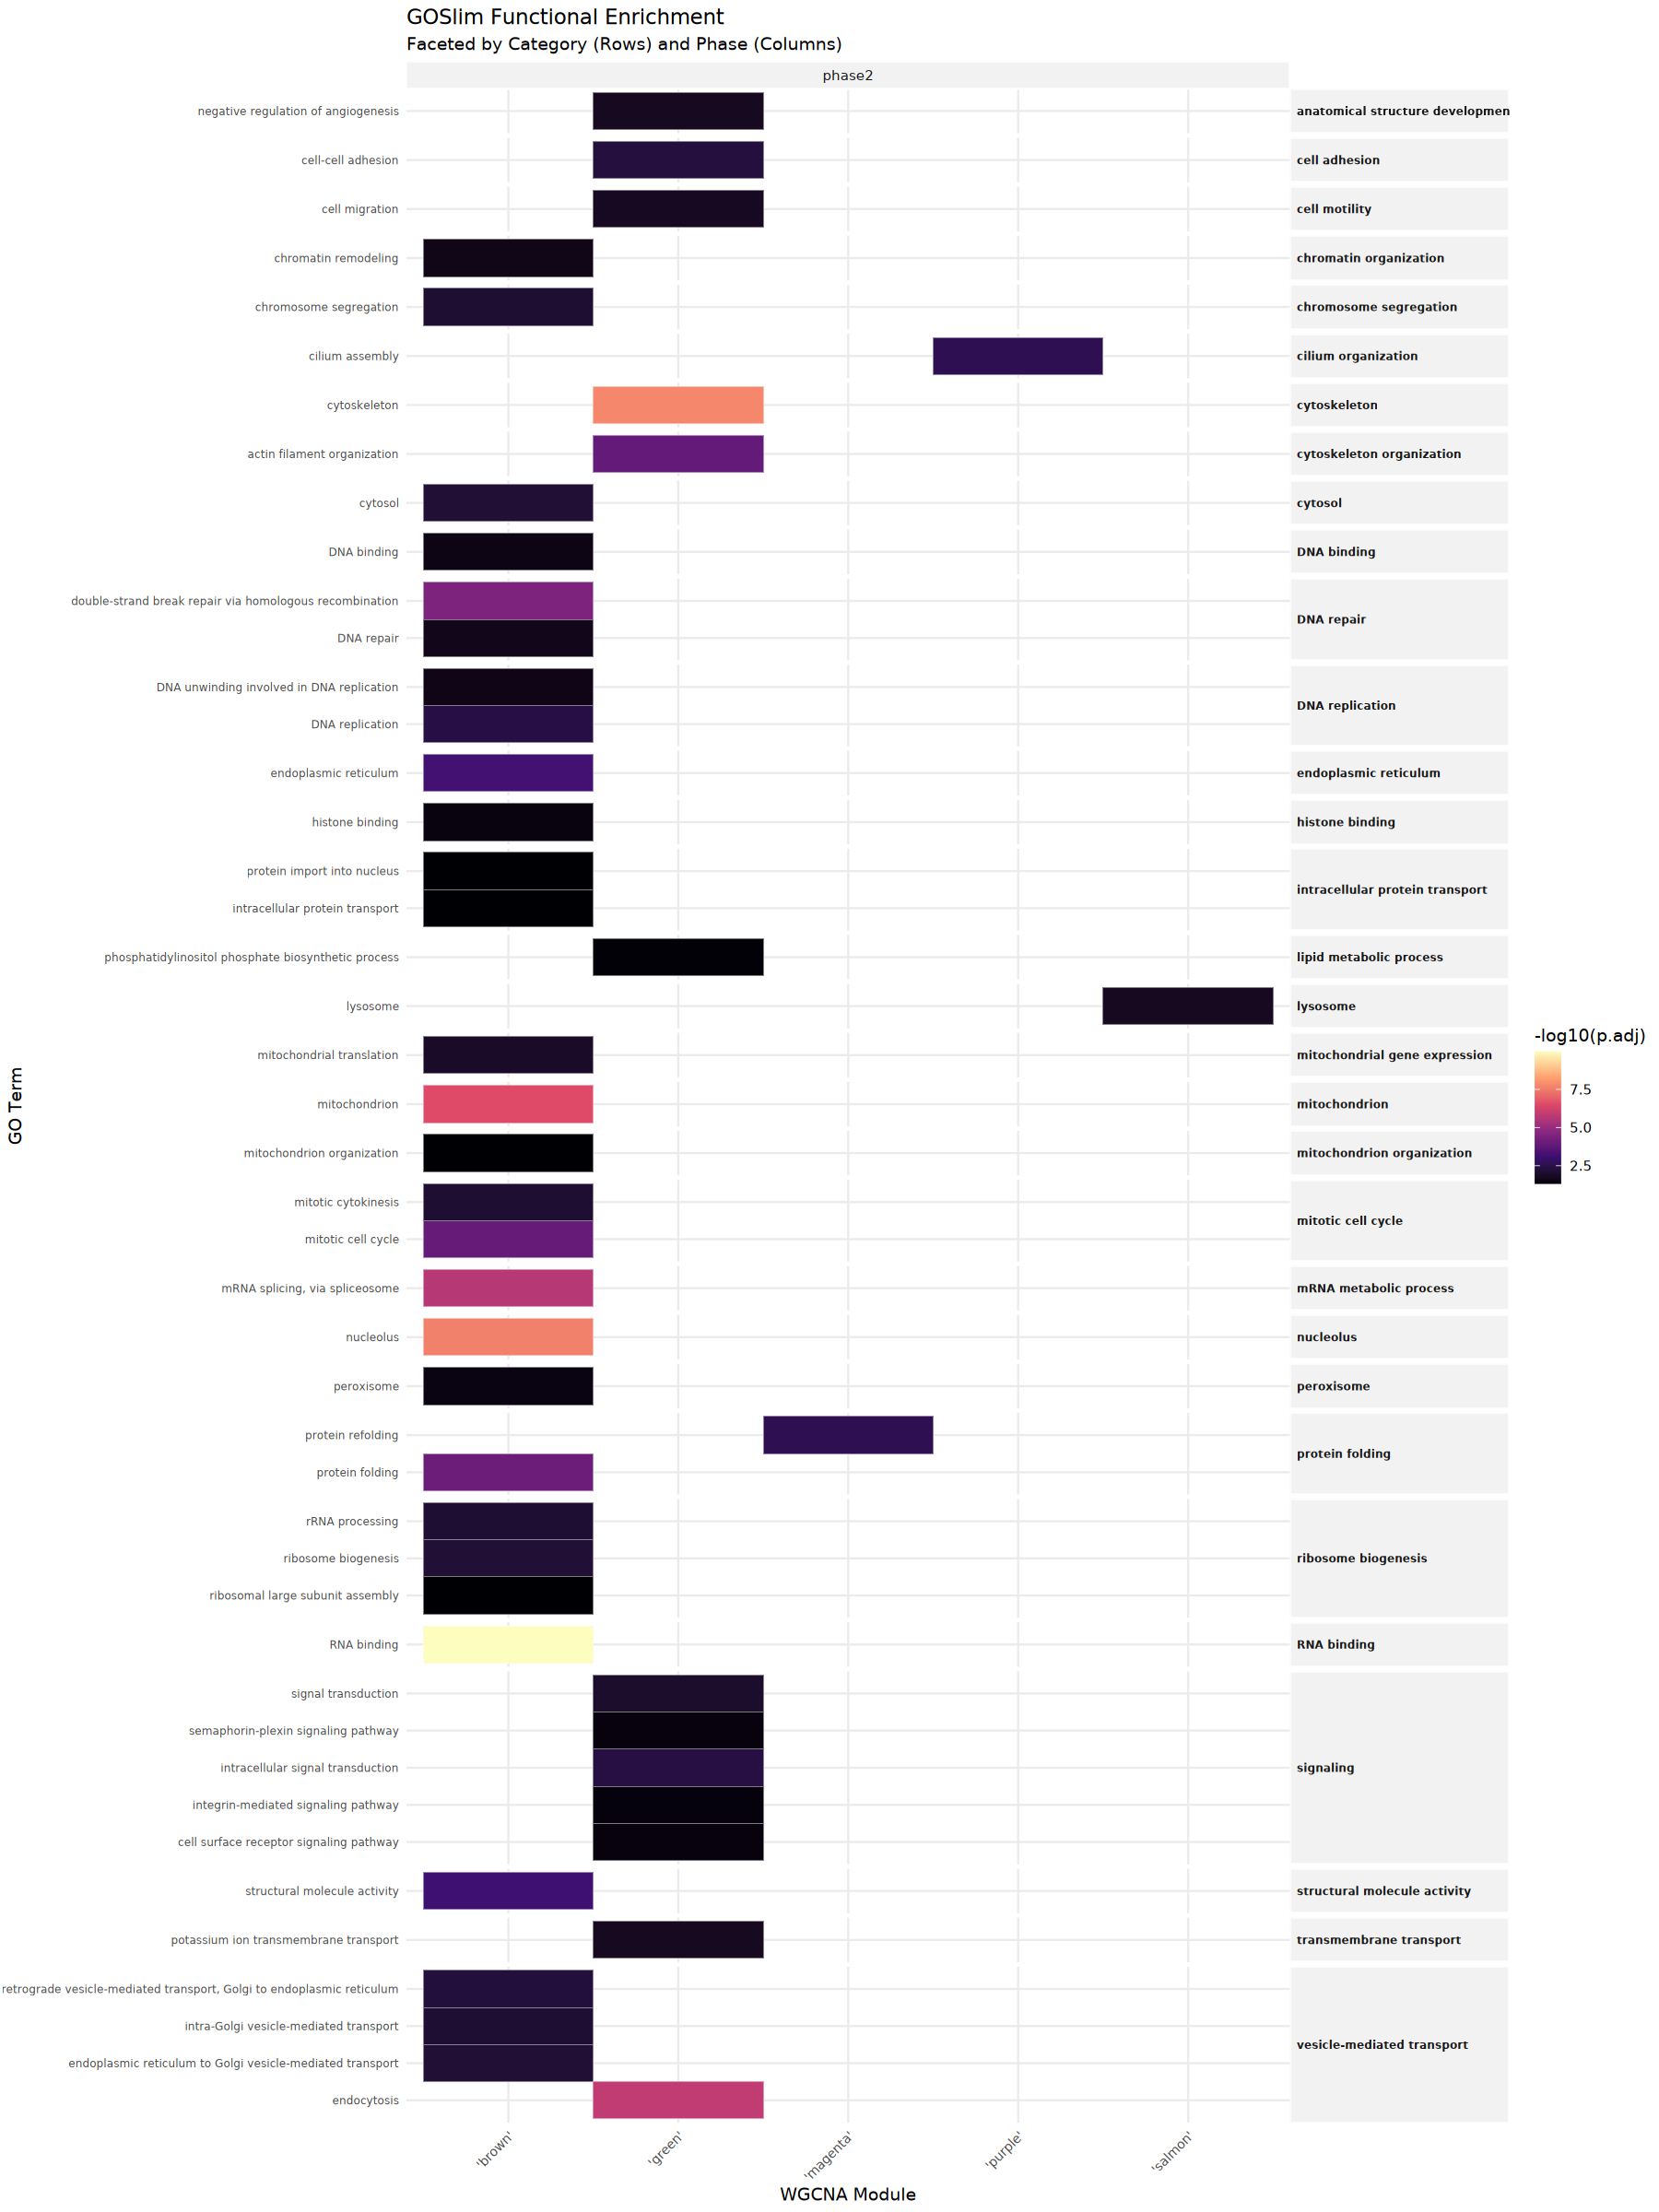

In [70]:
options(repr.plot.width = 15, repr.plot.height = 20)

ggplot(module.GO, aes(x = module, y = Description, fill = -log10(p.adjust))) +
  geom_tile(color = "white", linewidth = 0.1) + 
  # Rows = GOSlim_Bin, Columns = sigCor_phase
facet_grid(GOSlim_Bin ~ sigCor_phase, scales = "free", space = "free") +
scale_fill_viridis_c(option = "magma", name = "-log10(p.adj)") +
  theme_minimal() +
  theme(
    strip.text.y = element_text(angle = 0, size = 7, face = "bold", hjust = 0),
    strip.background = element_rect(fill = "gray95", color = "white"),
    axis.text.y = element_text(size = 7),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
    panel.spacing = unit(0.2, "lines"),
    legend.position = "right"
  ) +
  labs(
    title = "GOSlim Functional Enrichment",
    subtitle = "Faceted by Category (Rows) and Phase (Columns)",
    y = "GO Term",
    x = "WGCNA Module"
  )

what if we remove GO terms - look at just GOSlim categories

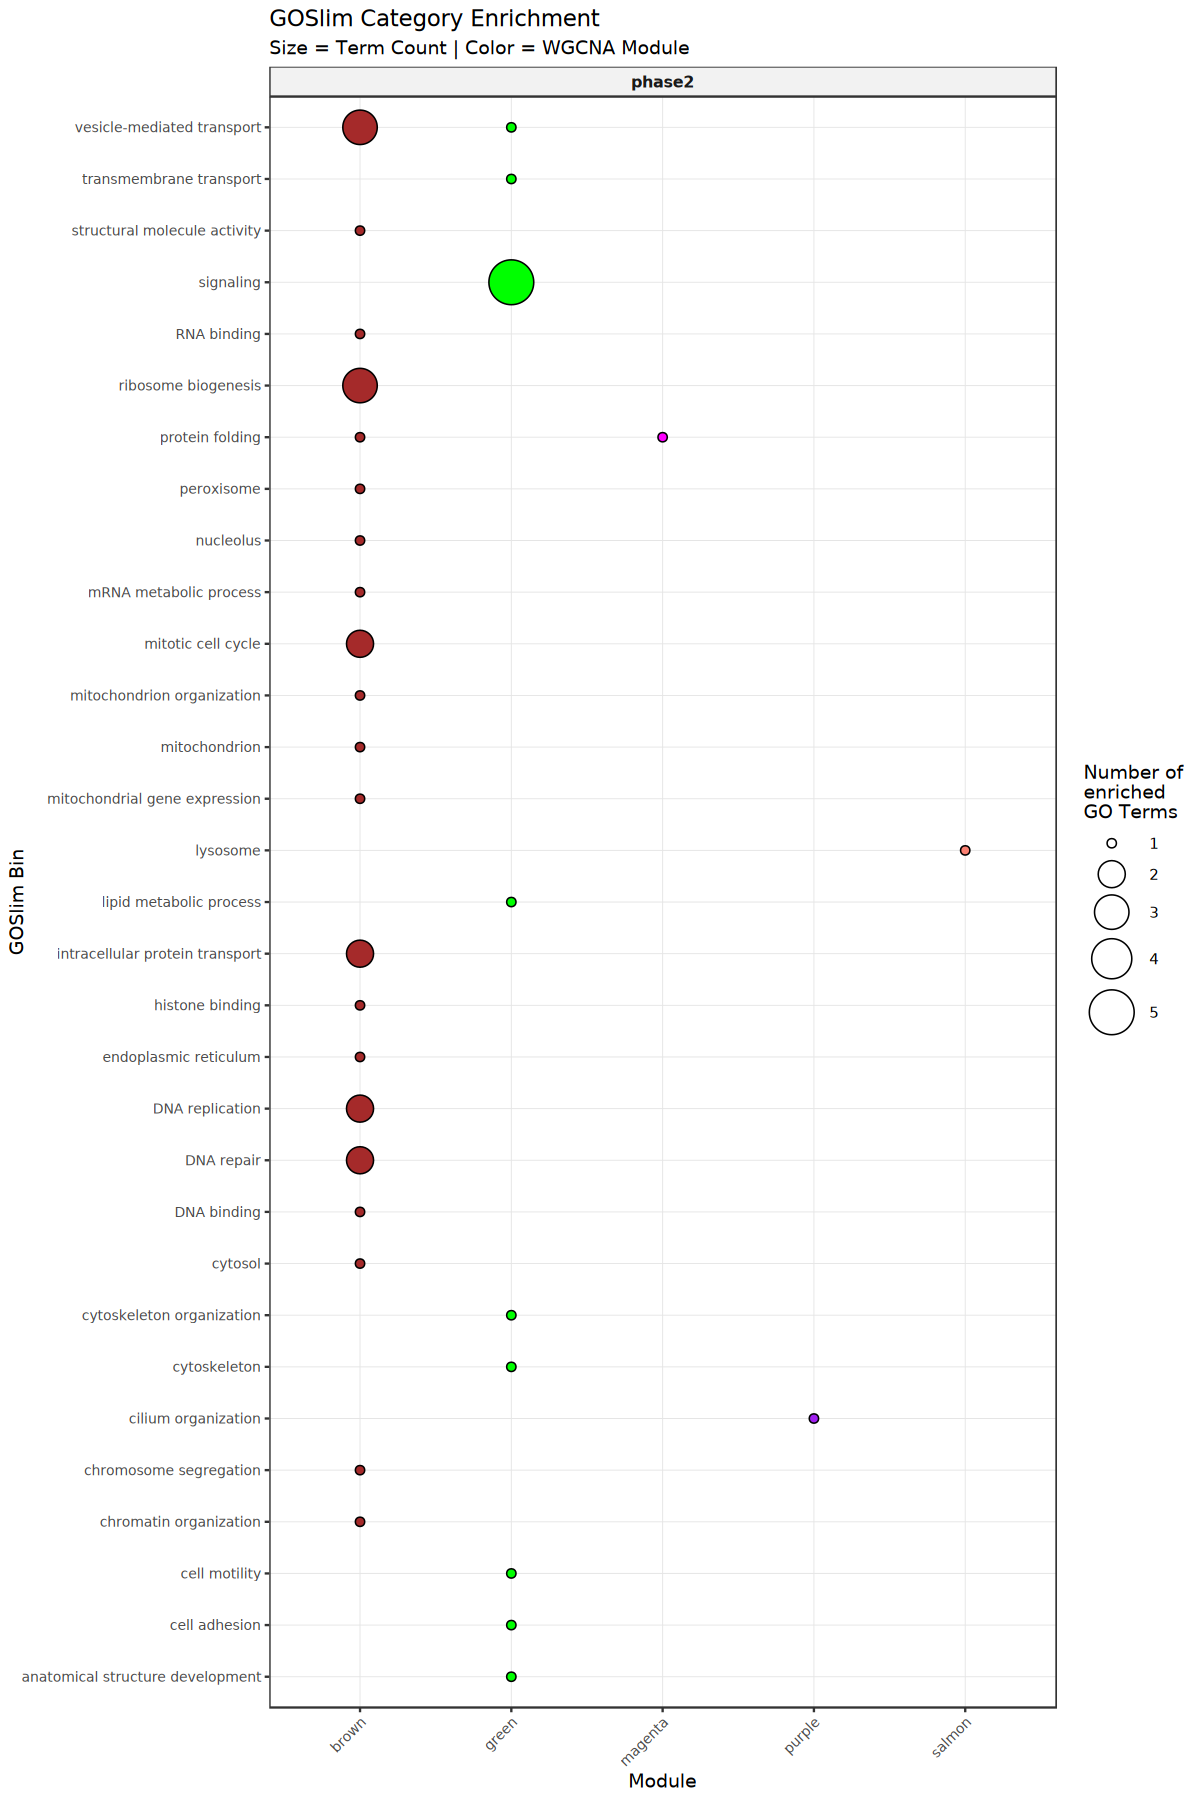

In [73]:
options(repr.plot.width = 10, repr.plot.height = 15)

# 1. Clean the strings and summarize
plot_summary <- module.GO %>%
  filter(!is.na(GOSlim_Bin), GOSlim_Bin != "", !is.na(sigCor_phase)) %>%
  # CLEANING STEP: Remove single quotes if they exist (e.g., 'green' -> green)
  mutate(module = str_replace_all(module, "'", "")) %>%
  group_by(module, GOSlim_Bin, sigCor_phase) %>%
  dplyr::summarize(GO_Count = n(), .groups = 'drop') %>% 
  mutate(across(where(is.character), as.factor))

plot_summary <- droplevels(plot_summary)

# 2. Plot with black outlines (shape 21)
ggplot(plot_summary, aes(x = module, y = GOSlim_Bin)) +
  # shape 21 uses 'fill' for the center and 'color' for the border
  geom_point(aes(size = GO_Count, fill = module), shape = 21, color = "black", stroke = 0.5) + 
  facet_grid(. ~ sigCor_phase, scales = "free_x", space = "free_x") +
  # Tell ggplot to use the literal module names for the fill
  scale_fill_identity() + 
  scale_size_continuous(range = c(2, 12), name = "Number of\nenriched\nGO Terms") +
  theme_bw() +
  theme(
    strip.text.x = element_text(size = 9, face = "bold"),
    strip.background = element_rect(fill = "gray95"),
    axis.text.y = element_text(size = 8),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 8),
    panel.spacing = unit(1, "lines"),
    panel.grid.major = element_line(color = "gray90", size = 0.2)
  ) +
  labs(
    title = "GOSlim Category Enrichment",
    subtitle = "Size = Term Count | Color = WGCNA Module",
    y = "GOSlim Bin",
    x = "Module"
  )

here, the phase 1 column is for modules associated with phase 1 treatments (treatment as a whole or isolated temp/DO), and same for phase 2 - these results are from oysters that experienced both phase 1 *and* 2